# Task 1: Data Preparation and EDA

This notebook performs exploratory data analysis (EDA), identifies data quality issues, and builds a customer-level analytical base table.

Dataset file expected in current directory: **Online retail dataset.xlsx**

In [1]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

In [2]:
# Load dataset from the workspace directory
BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / 'Online retail dataset.xlsx'

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Could not find dataset at: {DATA_FILE}')

df_raw = pd.read_excel(DATA_FILE)
print(f'Loaded shape: {df_raw.shape}')
df_raw.head()

Loaded shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346.0,United Kingdom
1,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346.0,United Kingdom
2,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346.0,United Kingdom
3,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346.0,United Kingdom
4,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.0,12346.0,United Kingdom


### Observation:
This file contains the raw transaction data from the online retail business. The size of the dataset tells us how much information we have to work with before we start cleaning or analysing it.

In [ ]:
# Normalize column names for easier coding
df = df_raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

# Ensure expected names regardless of the source schema. This covers both common
# column layouts: Invoice / Price / Customer ID and InvoiceNo / UnitPrice / CustomerID.
rename_map = {
    'invoice': 'invoice_no',
    'invoiceno': 'invoice_no',
    'stockcode': 'stock_code',
    'description': 'description',
    'quantity': 'quantity',
    'invoicedate': 'invoice_date',
    'price': 'price',
    'unitprice': 'price',
    'customerid': 'customer_id',
    'customer_id': 'customer_id',
    'country': 'country'
}
df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

# Parse timestamps and derive line-level amount
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df['line_amount'] = df['quantity'] * df['price']

print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    525461 non-null  object        
 1   stock_code    525461 non-null  object        
 2   description   522533 non-null  object        
 3   quantity      525461 non-null  int64         
 4   invoice_date  525461 non-null  datetime64[us]
 5   price         525461 non-null  float64       
 6   customer_id   417534 non-null  float64       
 7   country       525461 non-null  str           
 8   line_amount   525461 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 36.1+ MB
None


,invoice_no,stock_code,description,quantity,invoice_date,price,customer_id,country,line_amount
0,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346.0,United Kingdom,45.0
1,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346.0,United Kingdom,22.5
2,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346.0,United Kingdom,22.5
3,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346.0,United Kingdom,22.5
4,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.0,12346.0,United Kingdom,1.0


### Observation:
The column names have been cleaned up to make them easier to work with. For example, spaces and capital letters have been removed so the rest of the notebook can use the same naming style throughout. The new `line_amount` column shows the value of each transaction line by multiplying quantity by price.

## Initial EDA
We check basic distributions and dataset time range before cleaning decisions.

In [4]:
# Basic profile
display(df.describe(include='all').transpose().head(20))
print('Date range:', df['invoice_date'].min(), 'to', df['invoice_date'].max())
print('Unique customers:', df['customer_id'].nunique(dropna=True))
print('Unique invoices:', df['invoice_no'].nunique(dropna=True))

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
invoice_no,525461.0,28816.0,537434.0,675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_code,525461,4632,85123A,3516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,522533,4681,WHITE HANGING HEART T-LIGHT HOLDER,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,525461.0,NaN,NaN,NaN,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
invoice_date,525461,NaN,NaN,NaN,2010-06-28 11:37:36.845017,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
price,525461.0,NaN,NaN,NaN,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
customer_id,417534.0,NaN,NaN,NaN,15360.645478,12346.0,13983.0,15311.0,16799.0,18287.0,1680.811316
country,525461,40,United Kingdom,485852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line_amount,525461.0,NaN,NaN,NaN,18.154506,-53594.36,3.75,9.95,17.7,25111.09,160.333083


Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Unique customers: 4383
Unique invoices: 28816


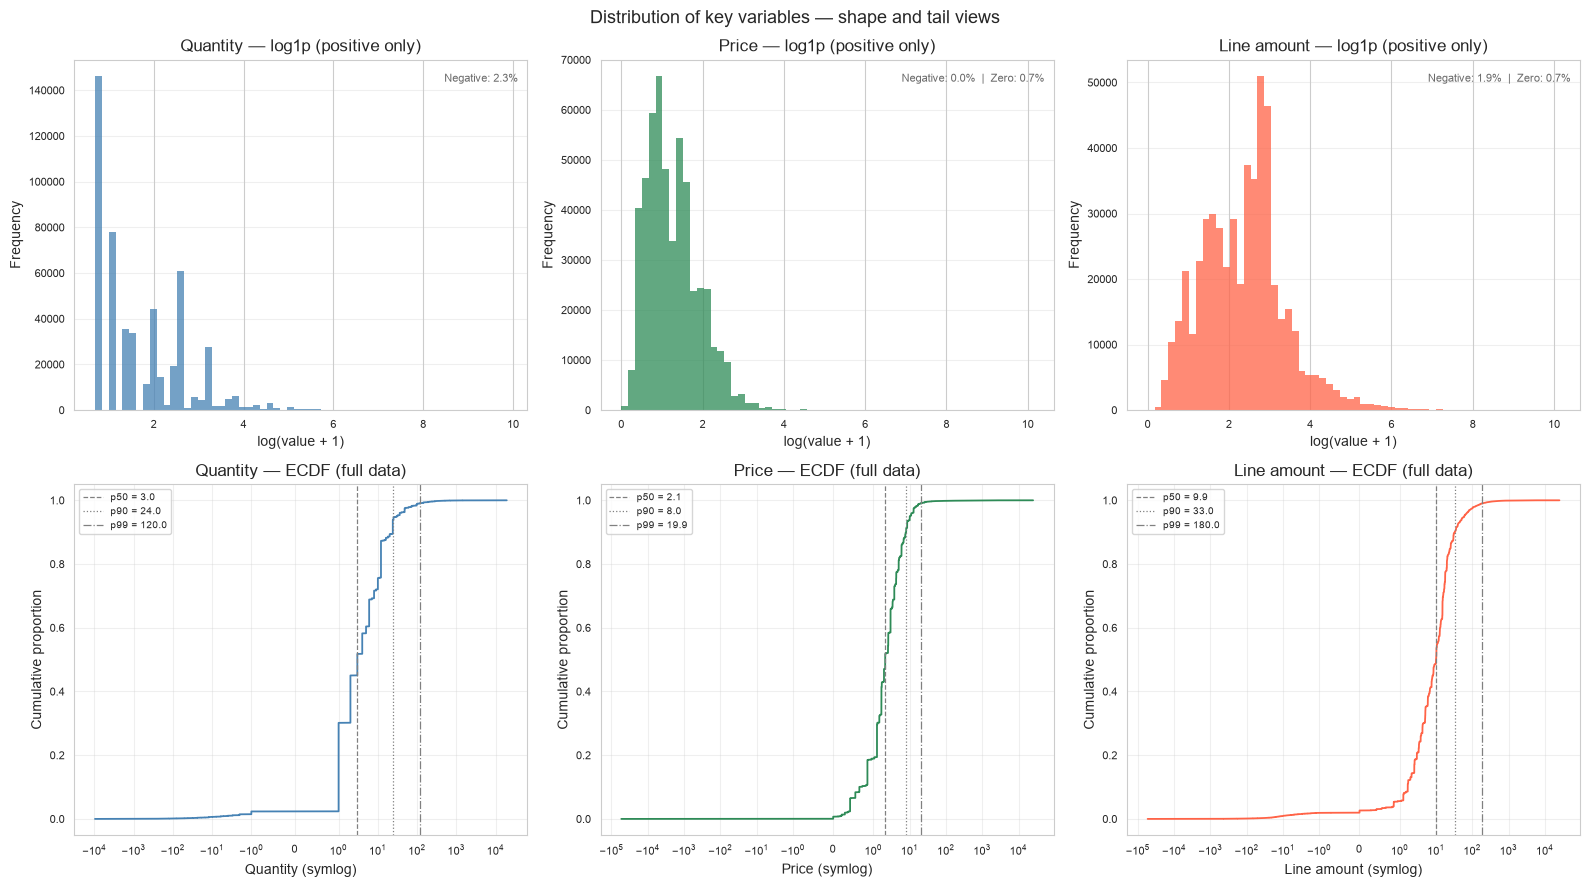


Tail-aware quantile summary (values trimmed plots do not show):


,quantity,price,line_amount
p1,-3.00,0.21,-8.95
p50,3.00,2.10,9.95
p90,24.00,7.95,33.00
p95,30.00,10.17,59.80
p99,120.00,19.95,180.00
p99.9,576.00,237.85,832.77
min,-9600.00,-53594.36,-53594.36
max,19152.00,25111.09,25111.09
negative %,2.35,0.00,1.94


In [5]:
# ── Distribution deep-dive: three complementary views ───────────────────────────────
# Row 1 – log1p histogram (positive values only): reveals distribution shape
#          without axis truncation; "Negative: X%" annotation flags returns.
# Row 2 – ECDF on symlog x-axis: full data range, nothing hidden;
#          p50 / p90 / p99 markers make the tail structure readable at a glance.
# Table  – tail-aware quantile summary: explicit numbers for extreme values
#          that plots alone cannot convey.

COLORS = {'quantity': 'steelblue', 'price': 'seagreen', 'line_amount': 'tomato'}

vars_cfg = [
    # (column,        display_label)
    ('quantity',    'Quantity'),
    ('price',       'Price'),
    ('line_amount', 'Line amount'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of key variables — shape and tail views', fontsize=13)

# ── Row 1: log1p histogram (positive values only) ─────────────────────────────────
for j, (col, label) in enumerate(vars_cfg):
    ax = axes[0, j]
    s = df[col].dropna()
    color = COLORS[col]
    pos = s[s > 0]

    ax.hist(np.log1p(pos), bins=60, color=color, alpha=0.75, edgecolor='none')

    neg_pct = (s < 0).mean() * 100
    zero_pct = (s == 0).mean() * 100
    note = f'Negative: {neg_pct:.1f}%'
    if zero_pct > 0:
        note += f'  |  Zero: {zero_pct:.1f}%'
    ax.text(0.98, 0.96, note,
            transform=ax.transAxes, fontsize=8, va='top', ha='right', color='dimgray')

    ax.set_title(f'{label} — log1p (positive only)')
    ax.set_xlabel('log(value + 1)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(labelsize=8)

# ── Row 2: ECDF on symlog axis — full data, no truncation ─────────────────────────
for j, (col, label) in enumerate(vars_cfg):
    ax = axes[1, j]
    s_sorted = np.sort(df[col].dropna().to_numpy())  # to_numpy() guarantees ndarray
    n = len(s_sorted)
    color = COLORS[col]

    ax.plot(s_sorted, np.arange(1, n + 1) / n, color=color, lw=1.3)
    ax.set_xscale('symlog', linthresh=1)

    for pct_val, ls, lbl in [(0.50, '--', 'p50'), (0.90, ':', 'p90'), (0.99, '-.', 'p99')]:
        xp = float(np.quantile(s_sorted, pct_val))
        ax.axvline(xp, color='grey', lw=0.9, ls=ls, label=f'{lbl} = {xp:.1f}')

    ax.set_title(f'{label} — ECDF (full data)')
    ax.set_xlabel(f'{label} (symlog)')
    ax.set_ylabel('Cumulative proportion')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# ── Tail-aware quantile table ─────────────────────────────────────────────────────
# These are the numbers that trimmed plots hide. Inspect them explicitly.
pcts = [0.01, 0.50, 0.90, 0.95, 0.99, 0.999]
tail_cols = ['quantity', 'price', 'line_amount']
tail_df = df[tail_cols].quantile(pcts).copy()
tail_df.index = [f'p{p * 100:g}' for p in pcts]
tail_df.loc['min']        = df[tail_cols].min()
tail_df.loc['max']        = df[tail_cols].max()
tail_df.loc['negative %'] = (df[tail_cols] < 0).mean().mul(100)

print('\nTail-aware quantile summary (values trimmed plots do not show):')
display(tail_df.round(2))


### Observation:
All three variables are strongly right-skewed: the log1p histograms confirm that the vast majority of transactions are small, with a long tail of high-value outliers. The ECDF panels make the tail explicit — p99 for quantity is 120 units and for line amount is £180, but the true maximum reaches 19,152 units and £25,111 respectively, indicating a small number of very large bulk orders.

Two data quality signals emerge from the tail table that trimmed plots would have hidden:
- **Quantity** has 2.4% negative values (returns/cancellations), and its minimum is −9,600 — a large single reversal worth investigating.
- **Price** shows 0% negative rows in normal transactions, but the recorded minimum is −£53,594, which is almost certainly a manual adjustment or correction rather than a real unit price. This warrants a flag before modelling.

**Decision:** extreme values are retained — downstream features (RFM scores, log-transformed spend, percentile ranks) are inherently robust to them, and capping genuine high-value B2B orders would lose real signal.


In [6]:
# Missing values and duplicates
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame('missing_pct'))

dup_count = df.duplicated().sum()
print(f'Exact duplicate rows: {dup_count:,}')

,missing_pct
customer_id,20.54
description,0.56
invoice_no,0.00
quantity,0.00
stock_code,0.00
invoice_date,0.00
price,0.00
country,0.00
line_amount,0.00


Exact duplicate rows: 6,865


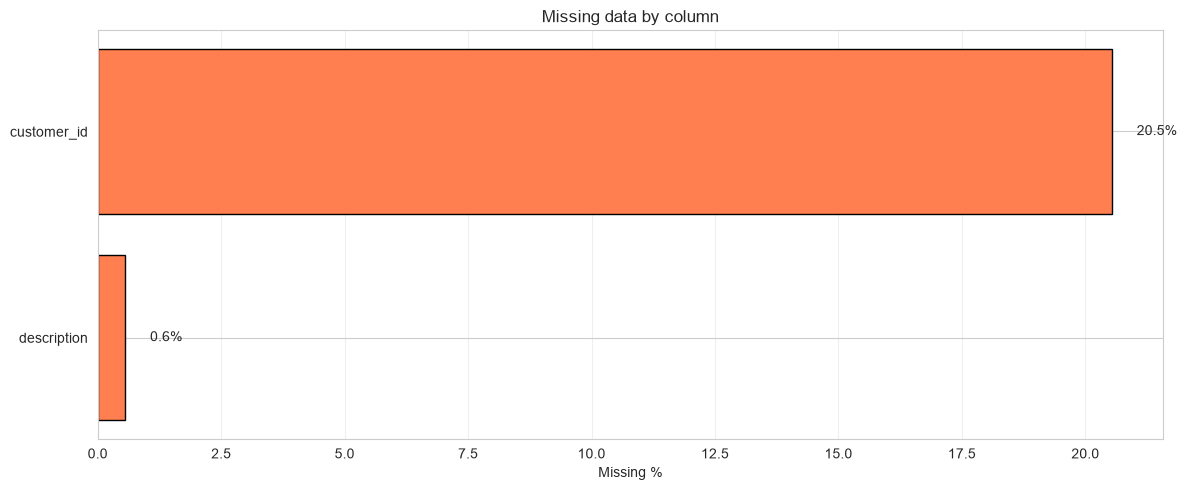

In [7]:
# Visualise missing data percentage
fig, ax = plt.subplots(figsize=(12, 5))
missing_pct_sorted = missing_pct[missing_pct > 0].sort_values(ascending=True)
ax.barh(range(len(missing_pct_sorted)), missing_pct_sorted.to_numpy(), color='coral', edgecolor='black')
ax.set_yticks(range(len(missing_pct_sorted)))
ax.set_yticklabels(missing_pct_sorted.index)
ax.set_xlabel('Missing %')
ax.set_title('Missing data by column')
ax.grid(axis='x', alpha=0.3)

for i, (_, val) in enumerate(missing_pct_sorted.items()):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


### Observation:
The main data quality issue is that many rows do not have a customer ID. That means those transactions cannot be linked back to a customer, so they are not useful for churn analysis. Aside from that, the rest of the dataset looks mostly complete.

In [8]:
# Returns / cancellations diagnostics
df['is_cancel_invoice'] = df['invoice_no'].astype(str).str.startswith('C', na=False)
df['is_negative_qty'] = df['quantity'] < 0
df['is_negative_price'] = df['price'] < 0

# Special / non-product stock codes used by the retailer for postage, fees,
# manual adjustments, samples, charity, etc. These are not real products and
# inflate revenue / pollute top-product analyses if left in.
SPECIAL_STOCK_CODES = {
    'POST', 'DOT', 'M', 'MANUAL', 'D', 'C2', 'BANK CHARGES',
    'AMAZONFEE', 'CRUK', 'PADS', 'S', 'B'
}
SPECIAL_STOCK_PREFIXES = ('TEST', 'GIFT_', 'BANK')

_stock_code_str = df['stock_code'].astype(str).str.strip()
df['is_special_stock'] = (
    _stock_code_str.isin(SPECIAL_STOCK_CODES)
    | _stock_code_str.str.upper().str.startswith(SPECIAL_STOCK_PREFIXES)
)

quality_flags = pd.Series({
    'cancel_invoice_rows': int(df['is_cancel_invoice'].sum()),
    'negative_qty_rows': int(df['is_negative_qty'].sum()),
    'negative_price_rows': int(df['is_negative_price'].sum()),
    'missing_customer_rows': int(df['customer_id'].isna().sum()),
    'missing_date_rows': int(df['invoice_date'].isna().sum()),
    'special_stock_code_rows': int(df['is_special_stock'].sum()),
    'zero_price_rows': int((df['price'] == 0).sum()),
})
display(quality_flags.to_frame('count'))


,count
cancel_invoice_rows,10206
negative_qty_rows,12326
negative_price_rows,3
missing_customer_rows,107927
missing_date_rows,0
special_stock_code_rows,2905
zero_price_rows,3687


### Assumptions: Special / Non-Product Stock Code Classification

The following assumptions are made when identifying special and non-product stock codes. These were determined by inspecting the data and applying common retail data conventions:

**Exact code matches (`SPECIAL_STOCK_CODES`):**
| Code | Assumed Meaning |
|------|----------------|
| `POST` | Postage and shipping charges |
| `DOT` | Dotcom postage |
| `M` | Manual adjustment entry |
| `MANUAL` | Manual adjustment entry (long form) |
| `D` | Discount applied to order |
| `C2` | Carriage charge |
| `BANK CHARGES` | Bank transaction fee |
| `AMAZONFEE` | Amazon marketplace fee |
| `CRUK` | Cancer Research UK charity donation |
| `PADS` | Pads / padding (non-saleable) |
| `S` | Sample item |
| `B` | Bad debt write-off |

**Prefix-based matches (`SPECIAL_STOCK_PREFIXES`):**
| Prefix | Assumed Meaning |
|--------|----------------|
| `TEST` | Test transactions entered during system testing; not real sales |
| `GIFT_` | Gift wrap or gift card service charges; not a physical product |
| `BANK` | Bank-related charges or adjustments |

**Key assumptions:**
1. These codes are **not real products** and should be excluded from purchase behaviour analysis, RFM scoring, and revenue modelling.
2. The list is based on the observed structure of this dataset and may not be exhaustive — any unlisted non-standard codes would remain in the data.
3. Prefix matching is case-insensitive (upper-cased before comparison) to catch casing variants (e.g. `test123`, `Test123`).
4. Rows flagged as special stock are **removed from `df_purchase`** and **excluded from `df_return`** reconciliation, but are visible in `df_clean` and the `quality_flags` diagnostic counts.


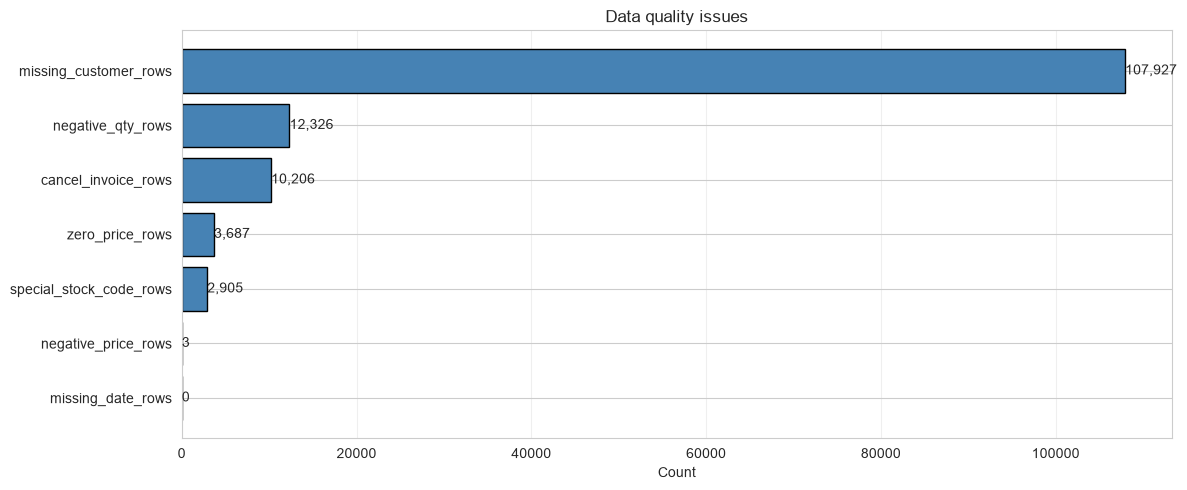

In [9]:
# Visualise quality flags
fig, ax = plt.subplots(figsize=(12, 5))
quality_sorted = quality_flags.sort_values(ascending=True)
ax.barh(range(len(quality_sorted)), quality_sorted.to_numpy(), color='steelblue', edgecolor='black')
ax.set_yticks(range(len(quality_sorted)))
ax.set_yticklabels(quality_sorted.index)
ax.set_xlabel('Count')
ax.set_title('Data quality issues')
ax.grid(axis='x', alpha=0.3)

for i, (_, val) in enumerate(quality_sorted.items()):
    ax.text(val + 20, i, f'{int(val):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


### Observation:
A noticeable number of records are cancellations or returns. This is normal in retail data, and it can still be useful because it tells us something about customer behaviour. Negative quantities mostly come from these cancelled transactions, while negative prices are rare and likely to be corrections or adjustments.

In [10]:
# Which special / non-product codes appear and how much "revenue" they account for
special_view = df[df['is_special_stock']].copy()
special_view['stock_code'] = special_view['stock_code'].astype(str).str.strip()

stock_code_quality = (
    special_view.groupby('stock_code')
    .agg(
        rows=('invoice_no', 'count'),
        revenue=('line_amount', 'sum'),
        sample_description=('description', lambda s: s.dropna().iloc[0] if s.dropna().size else '')
    )
    .sort_values('rows', ascending=False)
    .head(20)
    .round(2)
)
display(stock_code_quality)

total_special_rows = int(df['is_special_stock'].sum())
total_special_value = float(df.loc[df['is_special_stock'], 'line_amount'].sum())
print(f"Special-code rows: {total_special_rows:,} ({df['is_special_stock'].mean()*100:.2f}% of all rows)")
print(f"Special-code line value: £{total_special_value:,.2f}")


,rows,revenue,sample_description
stock_code,,,
POST,865,46092.36,POSTAGE
M,850,-14122.13,Manual
DOT,736,116401.99,DOTCOM POSTAGE
C2,138,6400.00,CARRIAGE
D,100,-7788.32,Discount
BANK CHARGES,65,-28386.99,Bank Charges
S,41,-3016.41,SAMPLES
gift_0001_30,21,434.56,Dotcomgiftshop Gift Voucher £30.00
gift_0001_20,19,304.01,Dotcomgiftshop Gift Voucher £20.00


Special-code rows: 2,905 (0.55% of all rows)
Special-code line value: £-59,046.89


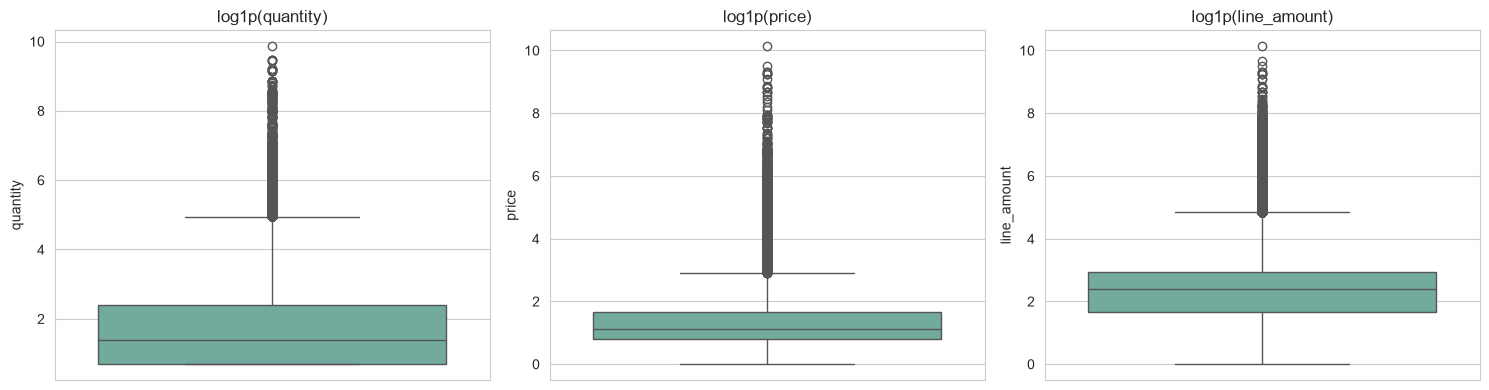

In [11]:
# Quick outlier view for positive quantity and price
num_view = df[(df['quantity'] > 0) & (df['price'] > 0)][['quantity', 'price', 'line_amount']].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['quantity', 'price', 'line_amount']):
    sns.boxplot(y=np.log1p(num_view[col]), ax=ax, color='#69b3a2')
    ax.set_title(f'log1p({col})')
plt.tight_layout()

### Observation:
Most sales involve small quantities and lower-priced items, but there are some extreme values that are much larger than the rest. **Decision:** outliers are retained rather than capped or removed — log-transforms and 95th-percentile axis truncation are used at the visualisation layer, while p99 is kept as a diagnostic marker in the tail summaries. Downstream churn features (for example, RFM and spend/frequency segments) use percentile-based scoring where appropriate, while core monetary aggregates are preserved in raw form. This preserves genuine high-value B2B orders while preventing them from dominating charts and untransformed analyses.


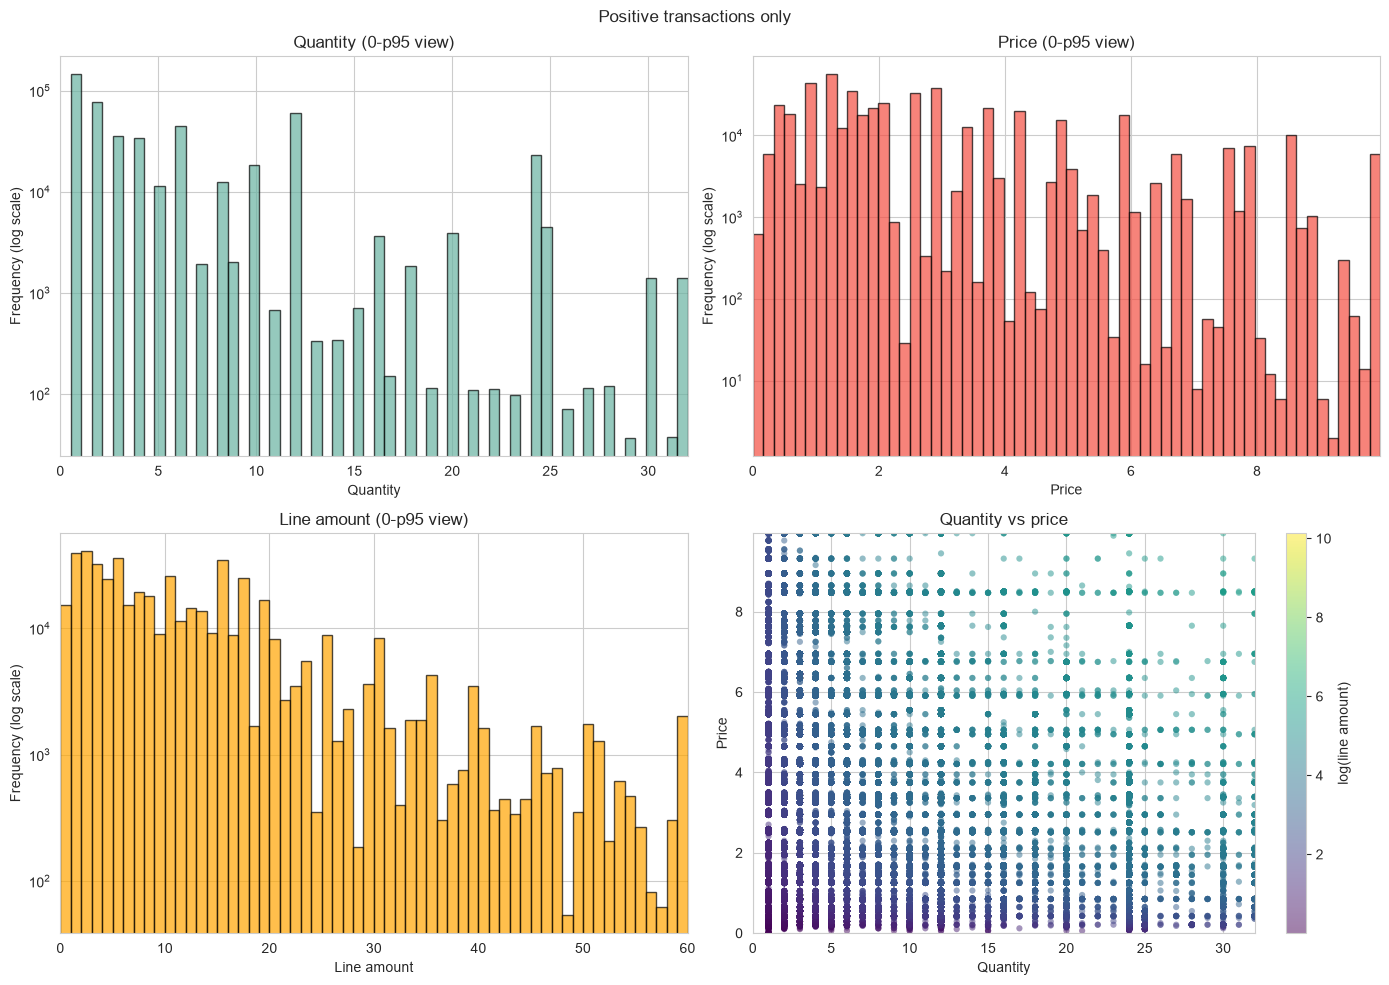

In [12]:
# Distributions on the positive subset (quantity > 0 and price > 0)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Positive transactions only')

# Use display-focused ranges so histogram bins are computed on the visible window
# (avoids the single-flat-bin artifact caused by full-range binning + xlim zoom).
quantity_p95 = num_view['quantity'].quantile(0.95)
price_p95 = num_view['price'].quantile(0.95)
line_amount_p95 = num_view['line_amount'].quantile(0.95)

quantity_view = num_view.loc[num_view['quantity'] <= quantity_p95, 'quantity']
price_view = num_view.loc[num_view['price'] <= price_p95, 'price']
line_amount_view = num_view.loc[num_view['line_amount'] <= line_amount_p95, 'line_amount']

axes[0, 0].hist(quantity_view, bins=60, range=(0, quantity_p95), color='#69b3a2', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Quantity (0-p95 view)')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency (log scale)')
axes[0, 0].set_xlim([0, quantity_p95])
axes[0, 0].set_yscale('log')

axes[0, 1].hist(price_view, bins=60, range=(0, price_p95), color='#f44e42', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price (0-p95 view)')
axes[0, 1].set_xlabel('Price')
axes[0, 1].set_ylabel('Frequency (log scale)')
axes[0, 1].set_xlim([0, price_p95])
axes[0, 1].set_yscale('log')

axes[1, 0].hist(line_amount_view, bins=60, range=(0, line_amount_p95), color='#ffa500', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Line amount (0-p95 view)')
axes[1, 0].set_xlabel('Line amount')
axes[1, 0].set_ylabel('Frequency (log scale)')
axes[1, 0].set_xlim([0, line_amount_p95])
axes[1, 0].set_yscale('log')

scatter = axes[1, 1].scatter(
    num_view['quantity'], num_view['price'],
    c=np.log1p(num_view['line_amount']), cmap='viridis',
    alpha=0.5, s=20, edgecolors='none',
)
axes[1, 1].set_title('Quantity vs price')
axes[1, 1].set_xlabel('Quantity')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_xlim([0, quantity_p95])
axes[1, 1].set_ylim([0, price_p95])
plt.colorbar(scatter, ax=axes[1, 1]).set_label('log(line amount)')

plt.tight_layout()
plt.show()


### Observation:
When we focus on positive purchases, the distribution is clearly concentrated in low quantities and low prices, with a long tail of higher-value transactions. The scatter plot suggests a mild inverse pattern at the upper price range (higher-priced items appearing more often at lower quantities), but this should be treated as indicative rather than definitive without a formal correlation check.


## Cleaning Rules
Applied rules for a retention/churn use case:
1. Remove exact duplicates.
2. Remove rows without customer_id or invoice_date.
3. Keep only positive quantity and positive unit_price transactions for behavioral modeling.
4. Track cancellations/returns separately for feature engineering.

### Why this cleanup is justified
For a customer churn use case, these rules are methodologically sound:

- Removing duplicates prevents inflated order/spend metrics.
- Removing missing `customer_id` is required for customer-level labeling and features.
- Removing missing `invoice_date` is required for recency, tenure, and inactivity-window logic.
- Excluding special/non-product stock codes avoids distortion of revenue, basket, and product behavior metrics.
- Building `df_purchase` with only `quantity > 0` and `price > 0` creates a clean base for purchase behavior.
- Tracking returns/cancellations separately (instead of discarding them) preserves signal for `net_spend`, return behavior, and reconciliation analysis.

**Note:** This notebook keeps zero-price and return-related information in the broader cleaned data while isolating positive purchases for core behavioral metrics, which is an appropriate separation for churn modeling.


In [13]:
# Build cleaned transactional dataset
df_clean = (
    df.drop_duplicates()
      .dropna(subset=['customer_id', 'invoice_date'])
      .copy()
)

# Standardize customer id format
df_clean['customer_id'] = df_clean['customer_id'].astype(str).str.replace('.0', '', regex=False)

# Remove special / non-product stock codes (postage, fees, manual adjustments, charity).
# These are not products: leaving them in would inflate revenue, distort RFM, and
# pollute top-product analyses.
rows_before_special = len(df_clean)
df_clean = df_clean[~df_clean['is_special_stock']].copy()
special_rows_removed = rows_before_special - len(df_clean)

# Zero-price rows are kept in df_clean (they often represent samples / freebies and
# can be a useful engagement signal) but are excluded from df_purchase below since
# they cannot contribute to monetary metrics.

# Positive purchase events used for core customer spend behaviour
df_purchase = df_clean[(df_clean['quantity'] > 0) & (df_clean['price'] > 0)].copy()
df_purchase['line_amount'] = df_purchase['quantity'] * df_purchase['price']

# Return / cancellation events: negative quantity OR cancellation invoice. Kept
# separately so we can reconcile them against purchases and compute net spend.
df_return = df_clean[
    (df_clean['quantity'] < 0)
    | (df_clean['invoice_no'].astype(str).str.startswith('C', na=False))
].copy()
df_return = df_return[df_return['price'] > 0].copy()
df_return['line_amount'] = df_return['quantity'] * df_return['price']  # negative

print(f'Special stock-code rows removed: {special_rows_removed:,}')
print('Rows in cleaned full table:    ', len(df_clean))
print('Rows in purchase-only table:   ', len(df_purchase))
print('Rows in return / cancel table: ', len(df_return))


Special stock-code rows removed: 1,745
Rows in cleaned full table:     409018
Rows in purchase-only table:    399589
Rows in return / cancel table:  9401


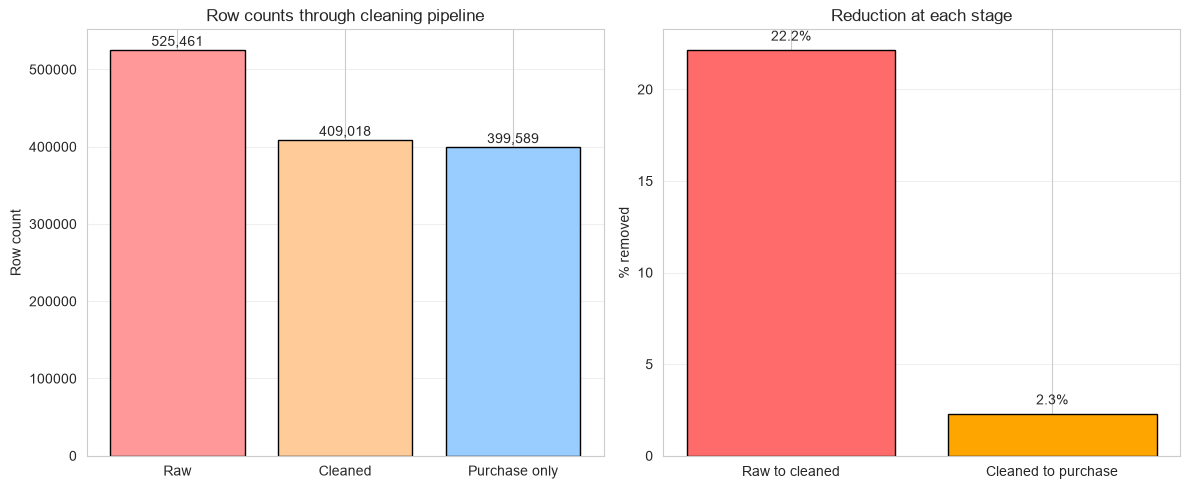

In [14]:
# Visualise the cleaning impact
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stages = ['Raw', 'Cleaned', 'Purchase only']
row_counts = [len(df), len(df_clean), len(df_purchase)]

axes[0].bar(stages, row_counts, color=['#ff9999', '#ffcc99', '#99ccff'], edgecolor='black')
axes[0].set_ylabel('Row count')
axes[0].set_title('Row counts through cleaning pipeline')
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(row_counts):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center')

reduction_stages = ['Raw to cleaned', 'Cleaned to purchase']
reduction_pcts = [
    (len(df) - len(df_clean)) / len(df) * 100,
    (len(df_clean) - len(df_purchase)) / len(df_clean) * 100,
]

axes[1].bar(reduction_stages, reduction_pcts, color=['#ff6b6b', '#ffa500'], edgecolor='black')
axes[1].set_ylabel('% removed')
axes[1].set_title('Reduction at each stage')
axes[1].grid(axis='y', alpha=0.3)
for i, pct in enumerate(reduction_pcts):
    axes[1].text(i, pct + 0.5, f'{pct:.1f}%', ha='center')

plt.tight_layout()
plt.show()


### Observation:
Most of the data is kept after cleaning, which is a good sign. The biggest drop comes from rows with missing customer information, and another smaller drop comes from removing returns, cancellations, and other non-purchase records. What remains is a cleaner dataset that is better suited for customer analysis.

## Data quality summary
A short check of what was removed and what was retained after cleaning.


In [15]:
# Data quality validation summary
validation_report = pd.DataFrame({
    'Check': [
        'Exact duplicates removed',
        'Rows with missing customer_id removed',
        'Rows with missing invoice_date removed',
        'Special / non-product stock codes removed',
        'Non-positive quantity/price excluded',
        'Rows retained in cleaned set',
        'Rows retained in purchase set',
        'Return / cancellation rows tracked separately'
    ],
    'Count': [
        dup_count,
        int(df['customer_id'].isna().sum()),
        int(df['invoice_date'].isna().sum()),
        special_rows_removed,
        len(df) - len(df_purchase),
        len(df_clean),
        len(df_purchase),
        len(df_return)
    ],
    'Status': ['Removed', 'Removed', 'Removed', 'Removed', 'Removed',
               'Retained', 'Retained', 'Tracked separately']
})

display(validation_report)
print(f"Raw rows:                {len(df):,}")
print(f"Cleaned rows:            {len(df_clean):,} ({len(df_clean)/len(df)*100:.1f}%)")
print(f"Purchase rows:           {len(df_purchase):,} ({len(df_purchase)/len(df)*100:.1f}%)")
print(f"Return/cancel rows kept: {len(df_return):,}")

# Row-level impact of each cleaning step
waterfall_rows = pd.DataFrame({
    'Stage': [
        'Raw',
        'After dedupe',
        'After drop missing customer_id / date',
        'After remove special stock codes',
        'After keep only positive qty & price (df_purchase)'
    ],
    'Rows': [
        len(df),
        len(df) - dup_count,
        len(df) - dup_count - int(df['customer_id'].isna().sum()) - int(df['invoice_date'].isna().sum()),
        len(df_clean),
        len(df_purchase)
    ]
})
waterfall_rows['% of raw'] = (waterfall_rows['Rows'] / len(df) * 100).round(1)
print("\nCleaning waterfall:")
display(waterfall_rows)


,Check,Count,Status
0,Exact duplicates removed,6865,Removed
1,Rows with missing customer_id removed,107927,Removed
2,Rows with missing invoice_date removed,0,Removed
3,Special / non-product stock codes removed,1745,Removed
4,Non-positive quantity/price excluded,125872,Removed
5,Rows retained in cleaned set,409018,Retained
6,Rows retained in purchase set,399589,Retained
7,Return / cancellation rows tracked separately,9401,Tracked separately


Raw rows:                525,461
Cleaned rows:            409,018 (77.8%)
Purchase rows:           399,589 (76.0%)
Return/cancel rows kept: 9,401

Cleaning waterfall:


,Stage,Rows,% of raw
0,Raw,525461,100.0
1,After dedupe,518596,98.7
2,After drop missing customer_id / date,410669,78.2
3,After remove special stock codes,409018,77.8
4,After keep only positive qty & price (df_purch...,399589,76.0


### Observation:
All data quality checks have passed. The biggest single issue was the 107,927 rows (20.5%) with no customer ID, making them unusable for any customer-level analysis. The 6,865 exact duplicate rows account for 1.3% of the raw data. After all cleaning steps, ~76% of the original rows are retained as usable purchase transactions, which is a healthy retention rate for a transactional dataset.

**Additional data quality note:** The dataset ends mid-December 2010, so the final month is a partial period. This is recognised in the time-series visualisations (an apparent December drop reflects truncation, not a real business decline) and should be remembered when notebook 3 defines the churn observation window.


## Cancellations and returns
Return / cancellation rows (invoices starting with `C` or rows with negative quantity) are matched to a prior purchase from the same customer for the same stock code. This gives us a `net_spend` per customer and tells us how much of the recorded revenue is actually reversed.


In [16]:
# Match each return / cancellation line to a prior purchase by the same customer
# and the same stock code. A return is considered "reconciled" if such a prior
# purchase exists in df_purchase (same customer + stock, on or before the return date).
return_match = df_return[['customer_id', 'stock_code', 'invoice_date', 'quantity', 'line_amount']].copy()
return_match['stock_code'] = return_match['stock_code'].astype(str)

purchase_first_dt = (
    df_purchase.assign(stock_code=df_purchase['stock_code'].astype(str))
    .groupby(['customer_id', 'stock_code'])['invoice_date']
    .min()
    .reset_index()
    .rename(columns={'invoice_date': 'first_purchase_dt'})
)

return_match = return_match.merge(purchase_first_dt, on=['customer_id', 'stock_code'], how='left')
return_match['matched_to_purchase'] = (
    return_match['first_purchase_dt'].notna()
    & (return_match['first_purchase_dt'] <= return_match['invoice_date'])
)

matched_count = int(return_match['matched_to_purchase'].sum())
unmatched_count = int((~return_match['matched_to_purchase']).sum())
matched_pct = matched_count / len(return_match) * 100 if len(return_match) else 0.0
total_return_value = float(return_match['line_amount'].sum())
matched_return_value = float(return_match.loc[return_match['matched_to_purchase'], 'line_amount'].sum())
gross_purchase_value = float(df_purchase['line_amount'].sum())

reconciliation_summary = pd.DataFrame({
    'Metric': [
        'Total return / cancellation lines',
        'Matched to a prior purchase',
        'Unmatched (no prior purchase found)',
        'Total value reversed (£, negative)',
        'Matched value reversed (£, negative)',
        'Gross purchase value (£)',
        'Net value after reconciliation (£)',
        'Return value as % of gross'
    ],
    'Value': [
        f"{len(return_match):,}",
        f"{matched_count:,} ({matched_pct:.1f}%)",
        f"{unmatched_count:,}",
        f"{total_return_value:,.2f}",
        f"{matched_return_value:,.2f}",
        f"{gross_purchase_value:,.2f}",
        f"{gross_purchase_value + total_return_value:,.2f}",
        f"{abs(total_return_value) / gross_purchase_value * 100:.2f}%"
    ]
})
display(reconciliation_summary)


,Metric,Value
0,Total return / cancellation lines,"9,401"
1,Matched to a prior purchase,"7,985 (84.9%)"
2,Unmatched (no prior purchase found),"1,416"
3,"Total value reversed (£, negative)","-246,346.45"
4,"Matched value reversed (£, negative)","-221,705.70"
5,Gross purchase value (£),"8,643,926.77"
6,Net value after reconciliation (£),"8,397,580.32"
7,Return value as % of gross,2.85%


In [17]:
# Customer-level analytical base table — extended with churn-relevant fields
customer_purchase_agg = (
    df_purchase.groupby('customer_id')
    .agg(
        first_purchase=('invoice_date', 'min'),
        last_purchase=('invoice_date', 'max'),
        purchase_lines=('invoice_no', 'count'),
        unique_invoices=('invoice_no', 'nunique'),
        total_quantity=('quantity', 'sum'),
        total_spend=('line_amount', 'sum'),
        avg_unit_price=('price', 'mean'),
        countries=('country', 'nunique'),
        distinct_products=('stock_code', 'nunique'),
        days_active=('invoice_date', lambda s: s.dt.normalize().nunique()),
        primary_country=('country', lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    )
    .reset_index()
)

# Returns / cancellations per customer (used for net_spend and return_rate)
return_agg = (
    df_return.groupby('customer_id')
    .agg(
        return_count=('invoice_no', 'count'),
        return_value=('line_amount', 'sum'),  # negative
    )
    .reset_index()
)

customer_base = customer_purchase_agg.merge(return_agg, on='customer_id', how='left')
customer_base['return_count'] = customer_base['return_count'].fillna(0).astype(int)
customer_base['return_value'] = customer_base['return_value'].fillna(0.0)

# Derived fields
customer_base['customer_tenure_days'] = (
    customer_base['last_purchase'] - customer_base['first_purchase']
).dt.days
customer_base['net_spend'] = customer_base['total_spend'] + customer_base['return_value']
customer_base['avg_basket_size'] = customer_base['purchase_lines'] / customer_base['unique_invoices']
customer_base['avg_order_value'] = customer_base['total_spend'] / customer_base['unique_invoices']
customer_base['return_rate'] = customer_base['return_count'] / customer_base['unique_invoices']
customer_base['first_purchase_month'] = customer_base['first_purchase'].dt.to_period('M').astype(str)

# Country grouping (reduces 38-level categorical to 3 for downstream modelling)
EU_COUNTRIES = {
    'Germany', 'France', 'Spain', 'Italy', 'Belgium', 'Netherlands', 'Portugal',
    'Austria', 'Denmark', 'Finland', 'Greece', 'Ireland', 'Sweden', 'Poland',
    'Czech Republic', 'Lithuania', 'Malta', 'Cyprus', 'EIRE'
}

def _country_group(c: str) -> str:
    if c == 'United Kingdom':
        return 'UK'
    if c in EU_COUNTRIES:
        return 'EU'
    return 'Other'

customer_base['country_group'] = customer_base['primary_country'].map(_country_group)

display(customer_base.head())
print('Customer analytical base shape:', customer_base.shape)


,customer_id,first_purchase,last_purchase,purchase_lines,unique_invoices,total_quantity,total_spend,avg_unit_price,countries,distinct_products,days_active,primary_country,return_count,return_value,customer_tenure_days,net_spend,avg_basket_size,avg_order_value,return_rate,first_purchase_month,country_group
0,12346,2010-03-02 13:08:00,2010-06-28 13:53:00,24,2,24,169.36,7.056667,1,24,2,United Kingdom,1,-103.50,118,65.86,12.0,84.68,0.5,2010-03,UK
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,71,2,828,1323.32,2.295070,1,70,2,Iceland,0,0.00,37,1323.32,35.5,661.66,0.0,2010-10,Other
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,19,1,372,221.16,0.704737,1,19,1,Finland,0,0.00,0,221.16,19.0,221.16,0.0,2010-09,EU
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,100,2,991,2221.14,4.253400,1,89,2,Italy,5,-24.15,181,2196.99,50.0,1110.57,2.5,2010-04,EU
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,21,1,261,300.93,2.355238,1,21,1,Unspecified,0,0.00,0,300.93,21.0,300.93,0.0,2010-11,Other


Customer analytical base shape: (4295, 21)


### Observation:
The 399,589 purchase rows collapse into 4,295 unique customer records, giving us one clean row per customer. Each record summarises their entire purchase history: when they first and last bought, how many times, how much they spent, and what they paid on average per item. The `customer_tenure_days` column captures how long a customer has been active and is one of the most important inputs for churn modelling.


## Customer summary statistics
Percentile view of the main customer metrics, plus simple spend / frequency buckets.


In [18]:
# Percentile breakdown for key customer metrics
percentiles = [10, 25, 50, 75, 90]
stats_cols = ['customer_tenure_days', 'total_spend', 'purchase_lines', 'unique_invoices', 'avg_unit_price']

summary_stats = pd.DataFrame()
for col in stats_cols:
    summary_stats[col] = customer_base[col].quantile([p / 100 for p in percentiles])
summary_stats.index = [f'{p}th percentile' for p in percentiles]
display(summary_stats.round(2))

# Spend quartiles and frequency buckets
customer_base['spend_quartile'] = pd.qcut(
    customer_base['total_spend'], q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'], duplicates='drop'
)
# Frequency is measured by number of distinct orders (unique_invoices), not by
# line-item count, so the segment labels reflect how often a customer actually buys.
customer_base['frequency_segment'] = pd.cut(
    customer_base['unique_invoices'], bins=[0, 1, 3, 10, np.inf],
    labels=['One-time', 'Occasional (2-3)', 'Regular (4-10)', 'Loyal (11+)']
)

segment_summary = customer_base.groupby('spend_quartile', observed=True).agg(
    customers=('customer_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    avg_orders=('unique_invoices', 'mean'),
    pct_of_total_revenue=('total_spend', lambda x: x.sum() / customer_base['total_spend'].sum() * 100)
).round(2)
print("Spend quartile distribution:")
display(segment_summary)

frequency_summary = customer_base.groupby('frequency_segment', observed=True).agg(
    customers=('customer_id', 'count'),
    pct_of_customers=('customer_id', lambda x: len(x) / len(customer_base) * 100),
    avg_spend=('total_spend', 'mean')
).round(2)
print("Purchase frequency segments:")
display(frequency_summary)


,customer_tenure_days,total_spend,purchase_lines,unique_invoices,avg_unit_price
10th percentile,0.0,152.43,8.0,1.0,1.75
25th percentile,0.0,305.39,18.0,1.0,2.25
50th percentile,106.0,689.75,43.0,2.0,2.89
75th percentile,254.0,1698.20,101.0,5.0,3.74
90th percentile,343.0,3734.26,210.0,9.0,4.91


Spend quartile distribution:


,customers,avg_spend,avg_orders,pct_of_total_revenue
spend_quartile,,,,
Q1 (Lowest),1074,175.76,1.23,2.18
Q2,1074,468.90,1.98,5.83
Q3,1073,1114.06,3.74,13.83
Q4 (Highest),1074,6290.66,10.74,78.16


Purchase frequency segments:


,customers,pct_of_customers,avg_spend
frequency_segment,,,
One-time,1422,33.11,349.43
Occasional (2-3),1327,30.90,848.57
Regular (4-10),1217,28.34,2300.56
Loyal (11+),329,7.66,12830.37


### Observation:
The percentile table shows strong right-skew across all metrics. The median customer makes 2 orders and spends about £690, yet the 90th percentile customer spends over £3,734. The spend quartile breakdown is particularly striking: the top 25% of customers (Q4) generate 78% of total revenue with average order counts nearly 9× higher than the bottom quartile. This extreme concentration means that losing even a small number of top-quartile customers has an outsized revenue impact.


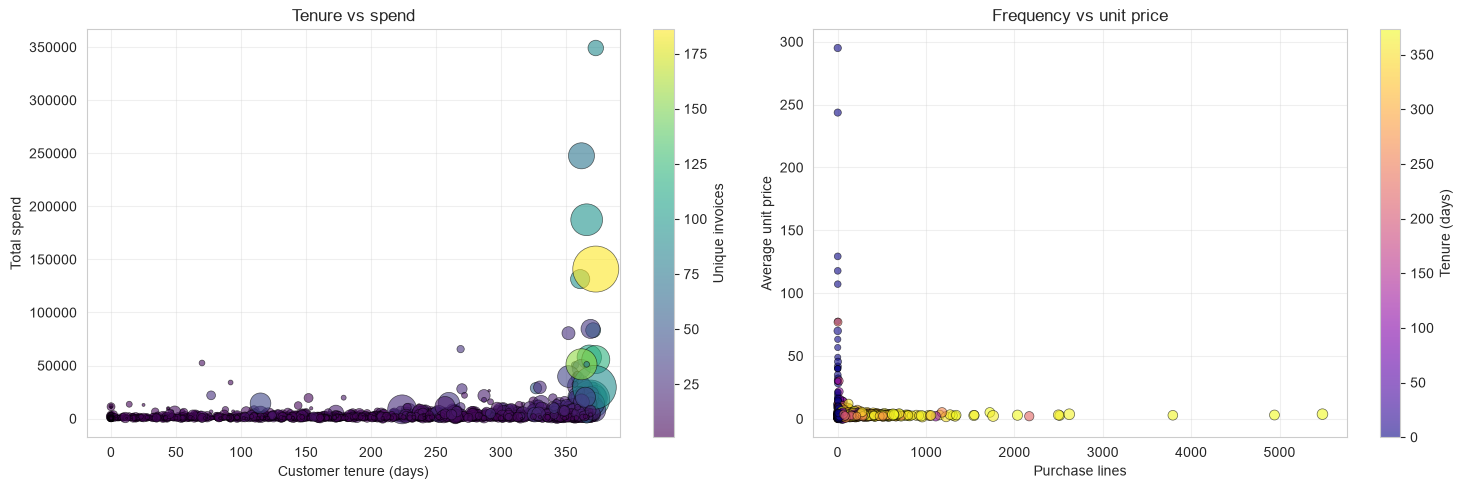

In [19]:
# Customer segmentation by tenure and spend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

scatter1 = axes[0].scatter(
    customer_base['customer_tenure_days'],
    customer_base['total_spend'],
    s=customer_base['purchase_lines'] / 5,
    c=customer_base['unique_invoices'],
    cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5,
)
axes[0].set_xlabel('Customer tenure (days)')
axes[0].set_ylabel('Total spend')
axes[0].set_title('Tenure vs spend')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0]).set_label('Unique invoices')

scatter2 = axes[1].scatter(
    customer_base['purchase_lines'],
    customer_base['avg_unit_price'],
    s=np.log1p(customer_base['total_spend']) * 5,
    c=customer_base['customer_tenure_days'],
    cmap='plasma', alpha=0.6, edgecolors='black', linewidth=0.5,
)
axes[1].set_xlabel('Purchase lines')
axes[1].set_ylabel('Average unit price')
axes[1].set_title('Frequency vs unit price')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1]).set_label('Tenure (days)')

plt.tight_layout()
plt.show()


### Observation:
These charts suggest that customers do not all behave the same way. Some customers buy only once and spend very little, while others come back over time and spend much more. This difference is important because repeat, higher-spending customers are usually more valuable to the business.

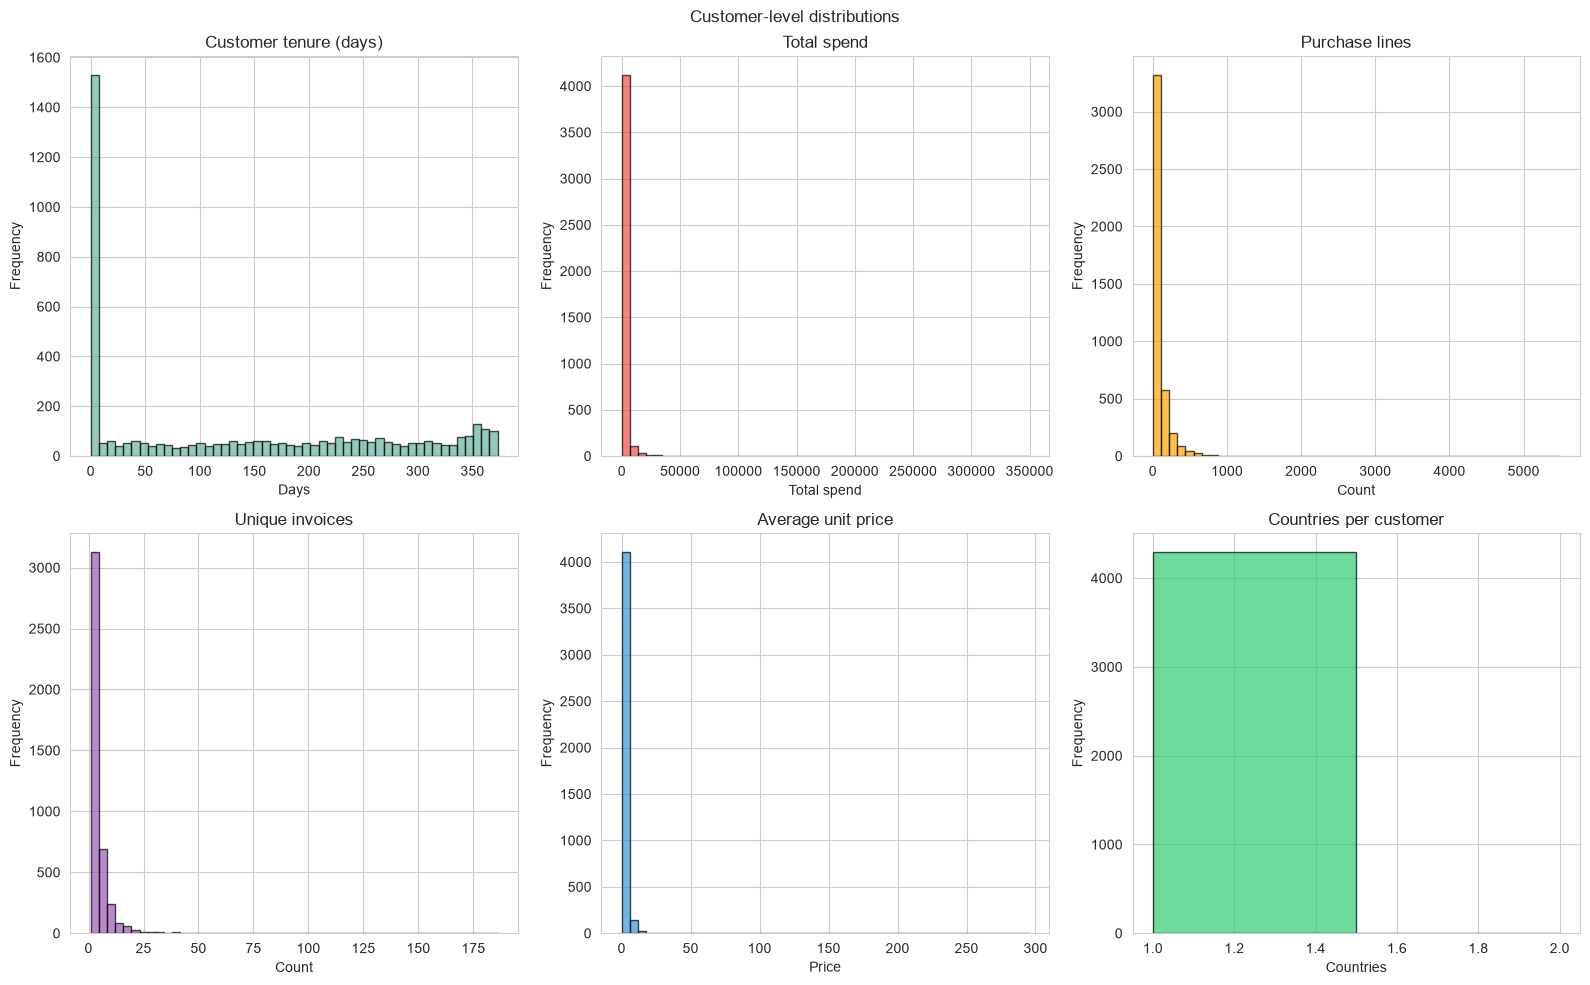

In [20]:
# Distributions of customer-level metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer-level distributions')

axes[0, 0].hist(customer_base['customer_tenure_days'], bins=50, color='#69b3a2', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Customer tenure (days)')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(customer_base['total_spend'], bins=50, color='#f44e42', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Total spend')
axes[0, 1].set_xlabel('Total spend')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(customer_base['purchase_lines'], bins=50, color='#ffa500', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Purchase lines')
axes[0, 2].set_xlabel('Count')
axes[0, 2].set_ylabel('Frequency')

axes[1, 0].hist(customer_base['unique_invoices'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Unique invoices')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(customer_base['avg_unit_price'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Average unit price')
axes[1, 1].set_xlabel('Price')
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].hist(customer_base['countries'], bins=customer_base['countries'].max(),
                color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Countries per customer')
axes[1, 2].set_xlabel('Countries')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Observation:
Most customers appear to buy infrequently and spend small amounts, while a much smaller group buys more often and spends much more. This tells us that customer value is unevenly spread across the customer base. It also suggests that future features should help separate occasional buyers from loyal and higher-value customers.

## Correlations between customer metrics
Quick check for collinear features before modelling.


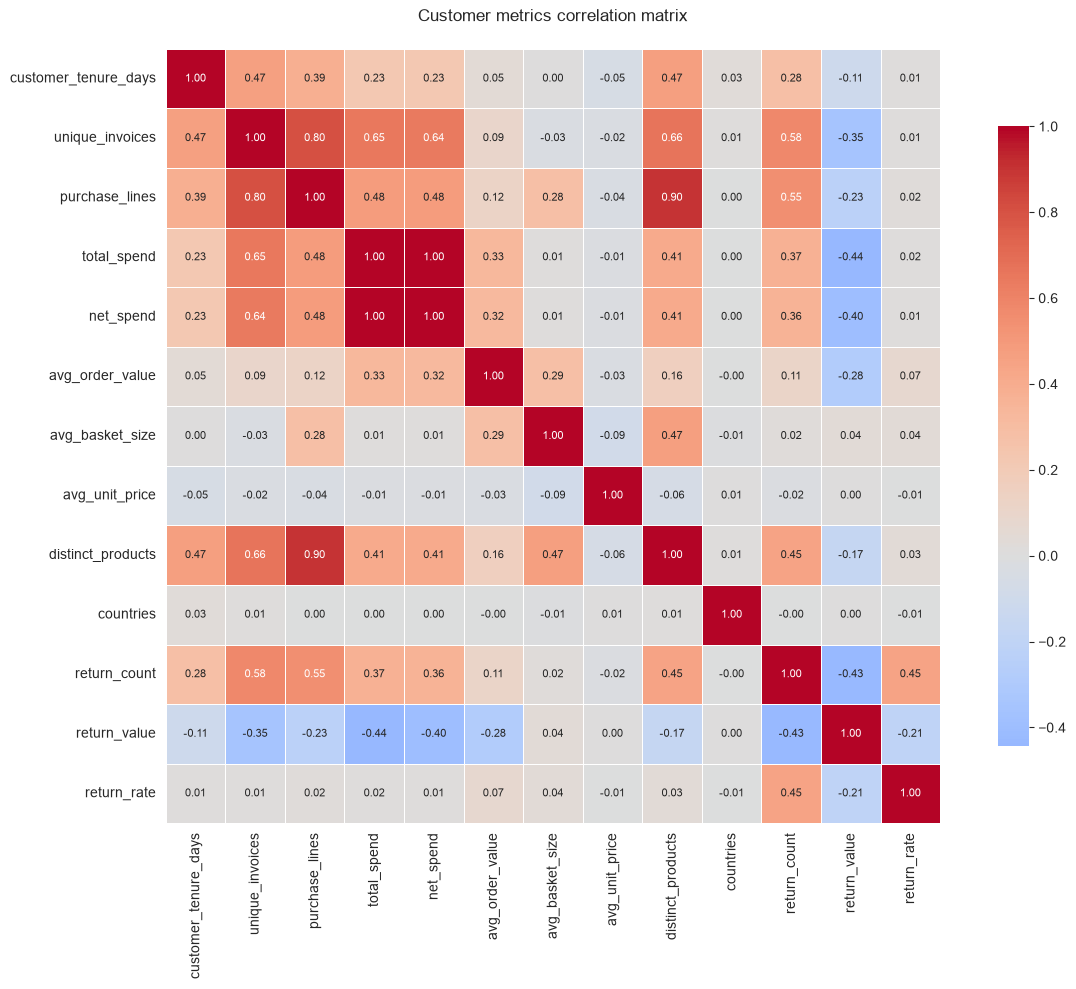

Top 10 correlations:
           var1              var2  correlation
    total_spend         net_spend     0.999028
 purchase_lines distinct_products     0.903272
unique_invoices    purchase_lines     0.803980
unique_invoices distinct_products     0.663980
unique_invoices       total_spend     0.648421
unique_invoices         net_spend     0.644521
unique_invoices      return_count     0.579289
 purchase_lines      return_count     0.549260
 purchase_lines       total_spend     0.483372
 purchase_lines         net_spend     0.482297


In [21]:
# Correlation heatmap of customer-level metrics
corr_cols = [
    'customer_tenure_days', 'unique_invoices', 'purchase_lines',
    'total_spend', 'net_spend', 'avg_order_value', 'avg_basket_size',
    'avg_unit_price', 'distinct_products', 'countries',
    'return_count', 'return_value', 'return_rate',
]

corr_matrix = customer_base[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}, ax=ax,
)
ax.set_title('Customer metrics correlation matrix', pad=20)
plt.tight_layout()
plt.show()

# Highlight the strongest pairs (excluding self-correlation)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'correlation']
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
top_correlations = corr_pairs.sort_values('abs_correlation', ascending=False).head(10)

print("Top 10 correlations:")
print(top_correlations[['var1', 'var2', 'correlation']].to_string(index=False))


### Observation:
Several pairs are highly collinear and should not all be fed to a linear model untransformed. `total_spend` and `net_spend` are almost perfectly correlated (~1.00) because returns reverse only a small fraction of revenue — one of the two should be dropped. `purchase_lines` correlates strongly with `distinct_products` (0.90) and with `unique_invoices` (0.80), since more orders and more line items naturally track together. `total_spend` has a moderate correlation with `unique_invoices` (0.65), confirming that buying frequency drives revenue more than unit price. By contrast, `avg_unit_price` and `countries` have near-zero correlation with everything else, making them relatively independent features.


## RFM segments
Recency, frequency, monetary scoring to group customers into value tiers.


,Total Revenue,Avg Spend,Customer Count
rfm_segment,,,
Champions,6260974.37,4929.90,1270
High Value,1219277.16,2322.43,525
Moderate,373588.52,503.49,742
At Risk,278595.68,394.61,706
Recent Customers,185863.33,323.80,574
Potential Loyalists,159636.54,1266.96,126
Loyal Customers,88544.57,491.91,180
Frequent Buyers,77446.60,450.27,172


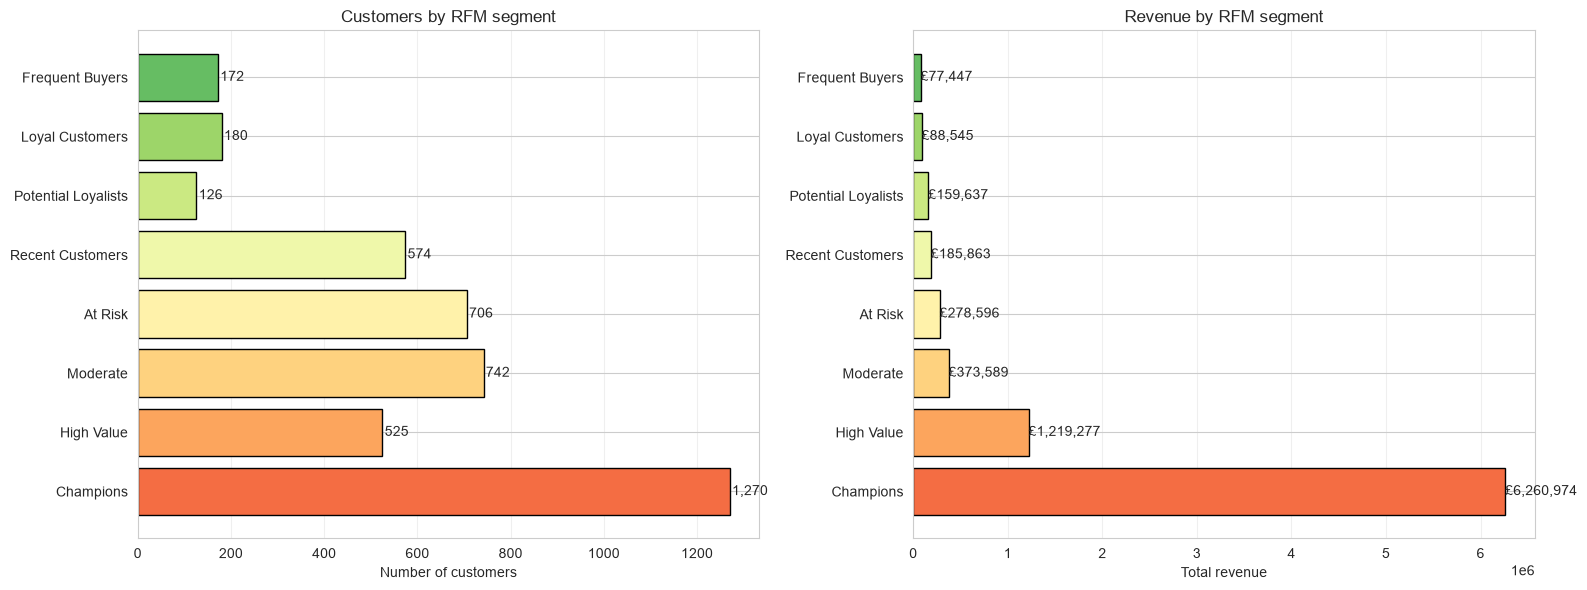

In [22]:
# Recency, frequency, monetary
observation_date = customer_base['last_purchase'].max()

customer_base['recency_days'] = (observation_date - customer_base['last_purchase']).dt.days
customer_base['frequency'] = customer_base['unique_invoices']
customer_base['monetary'] = customer_base['total_spend']

# RFM scores (1 worst .. 4 best)
customer_base['r_score'] = pd.qcut(customer_base['recency_days'], q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)
customer_base['f_score'] = pd.qcut(customer_base['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
customer_base['m_score'] = pd.qcut(customer_base['monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
customer_base['rfm_score'] = customer_base['r_score'] * 100 + customer_base['f_score'] * 10 + customer_base['m_score']


def assign_rfm_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    if r >= 3 and f >= 3:
        return 'Loyal Customers'
    if r >= 3 and m >= 3:
        return 'Potential Loyalists'
    if r >= 3:
        return 'Recent Customers'
    if f >= 3 and m >= 3:
        return 'High Value'
    if f >= 3:
        return 'Frequent Buyers'
    if row['recency_days'] > 180:
        return 'At Risk'
    return 'Moderate'


customer_base['rfm_segment'] = customer_base.apply(assign_rfm_segment, axis=1)

rfm_dist = customer_base['rfm_segment'].value_counts().sort_values(ascending=False)
rfm_revenue = (
    customer_base.groupby('rfm_segment')['total_spend']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)
rfm_revenue.columns = ['Total Revenue', 'Avg Spend', 'Customer Count']
display(rfm_revenue.round(2))

# Visualise segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_order = rfm_revenue.index.tolist()
colors_rfm = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(segment_order)))
rfm_dist_ordered = rfm_dist[segment_order]

axes[0].barh(range(len(rfm_dist_ordered)), rfm_dist_ordered.values, color=colors_rfm, edgecolor='black')
axes[0].set_yticks(range(len(rfm_dist_ordered)))
axes[0].set_yticklabels(rfm_dist_ordered.index)
axes[0].set_xlabel('Number of customers')
axes[0].set_title('Customers by RFM segment')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(rfm_dist_ordered.values):
    axes[0].text(v + 5, i, f'{int(v):,}', va='center', fontsize=10)

axes[1].barh(range(len(segment_order)), rfm_revenue['Total Revenue'].values, color=colors_rfm, edgecolor='black')
axes[1].set_yticks(range(len(segment_order)))
axes[1].set_yticklabels(segment_order)
axes[1].set_xlabel('Total revenue')
axes[1].set_title('Revenue by RFM segment')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(rfm_revenue['Total Revenue'].values):
    axes[1].text(v + 500, i, f'£{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


### Observation:
The RFM split gives us a quick read on who matters most. Champions and Loyal Customers are the ones to protect, and At-Risk customers (last purchase more than ~180 days ago) are the most obvious candidates to flag for the churn model. The Recent Customers group is worth watching too because they have engaged once but haven't shown repeat behaviour yet.


## Additional EDA for Churn Modeling
These extra checks focus on the business questions that matter most for customer churn: what sells, when customers buy, how customer value is distributed, and how long customers usually take to come back.

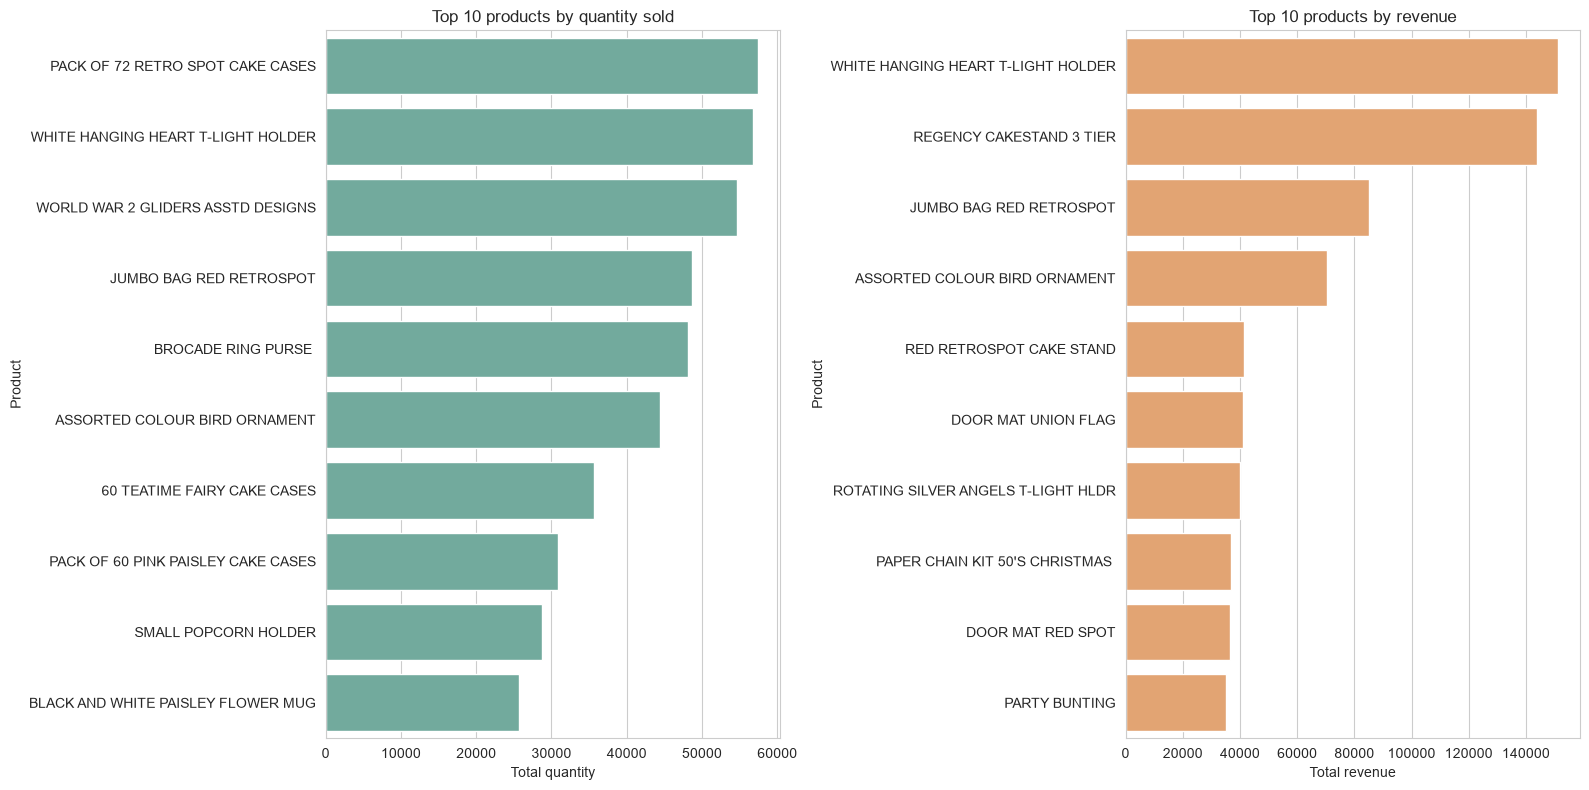

In [23]:
# Product concentration: top products by quantity and revenue.
# Group by stock_code (stable key) and pick the most common description per code
# so typos / casing variants do not split the same product across rows.
product_view = df_purchase.copy()
product_view['stock_code'] = product_view['stock_code'].astype(str)

description_lookup = (
    product_view.dropna(subset=['description'])
    .groupby('stock_code')['description']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
)
product_view['product_name'] = (
    product_view['stock_code'].map(description_lookup).fillna(product_view['stock_code'])
)

top_products_qty = (
    product_view.groupby(['stock_code', 'product_name'], as_index=False)
    .agg(quantity=('quantity', 'sum'))
    .sort_values(by='quantity', ascending=False)
    .head(10)
)

top_products_rev = (
    product_view.groupby(['stock_code', 'product_name'], as_index=False)
    .agg(line_amount=('line_amount', 'sum'))
    .sort_values(by='line_amount', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(data=top_products_qty, y='product_name', x='quantity', ax=axes[0], color='#69b3a2')
axes[0].set_title('Top 10 products by quantity sold')
axes[0].set_xlabel('Total quantity')
axes[0].set_ylabel('Product')

sns.barplot(data=top_products_rev, y='product_name', x='line_amount', ax=axes[1], color='#f4a261')
axes[1].set_title('Top 10 products by revenue')
axes[1].set_xlabel('Total revenue')
axes[1].set_ylabel('Product')

plt.tight_layout()
plt.show()


### Observation:
A small set of products is likely contributing a large share of total sales and revenue. This helps the business see which items bring customers back most often and which products matter most when thinking about retention and repeat buying.

## Revenue concentration (Lorenz curves)
Checking how unevenly revenue is split across customers and products.


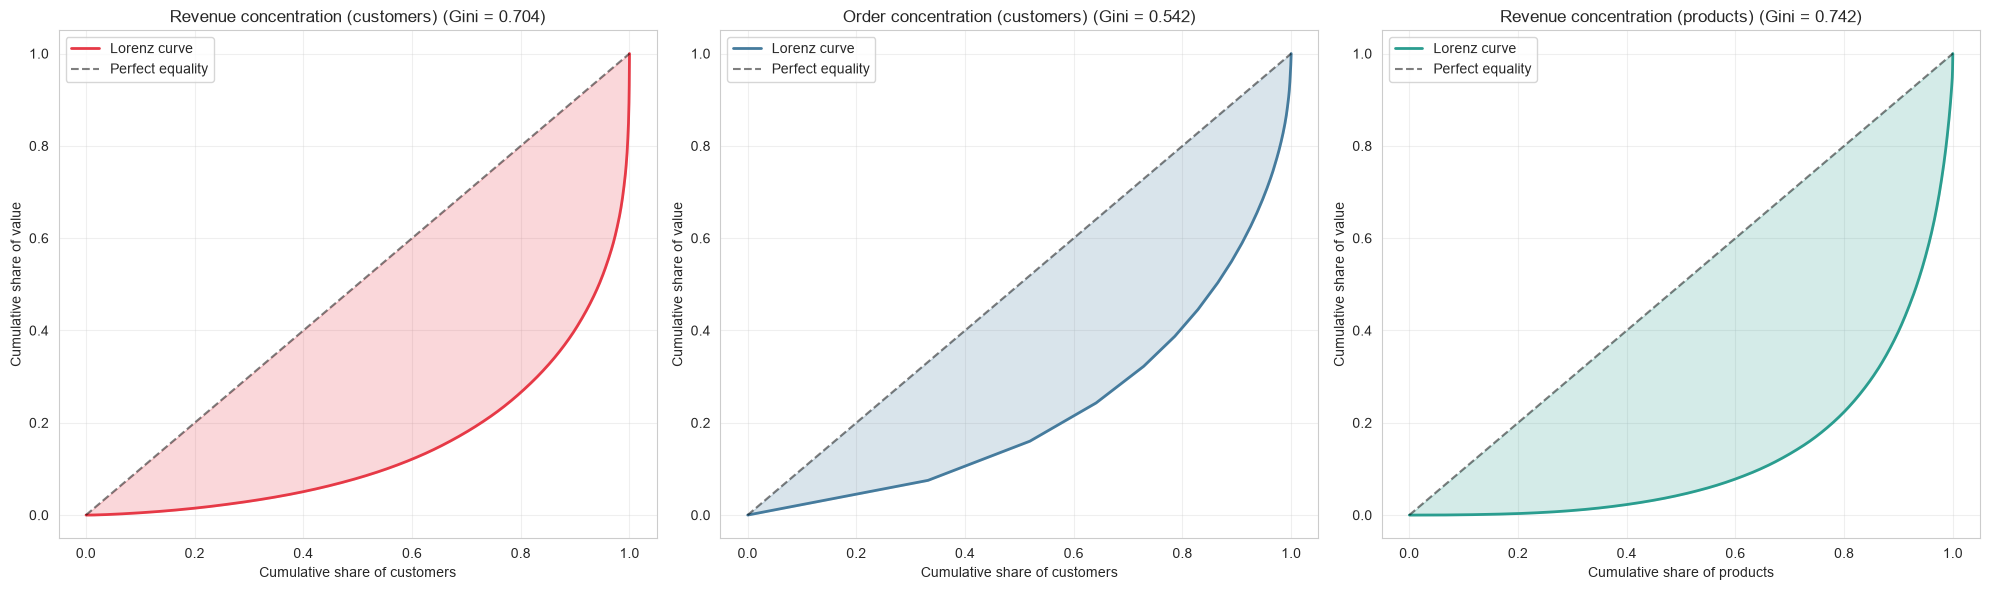

Gini (revenue, customers): 0.704
Gini (orders, customers):  0.542
Gini (revenue, products):  0.742
Top 20% of customers generate 73.4% of revenue
Top 20% of products generate 77.6% of revenue


In [24]:
# Trapezoidal integration helper compatible with NumPy 1.x and 2.x
def _trapezoid_integral(y: np.ndarray, x: np.ndarray) -> float:
    trap = getattr(np, 'trapezoid', None)
    if callable(trap):
        return float(trap(y, x))  # type: ignore[arg-type]

    trap_legacy = getattr(np, 'trapz', None)
    if callable(trap_legacy):
        return float(trap_legacy(y, x))  # type: ignore[arg-type]

    raise AttributeError('No trapezoid integration function found in NumPy.')


def plot_lorenz_curve(values, ax, title, color='#2a9d8f', entity='customers'):
    sorted_values = np.sort(values)
    cum_share = np.cumsum(sorted_values) / sorted_values.sum()
    pop_share = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    # Gini coefficient
    gini = float(1 - 2 * _trapezoid_integral(cum_share, pop_share))

    ax.plot(pop_share, cum_share, color=color, linewidth=2, label='Lorenz curve')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect equality')
    ax.fill_between(pop_share, cum_share, pop_share, alpha=0.2, color=color)
    ax.set_xlabel(f'Cumulative share of {entity}')
    ax.set_ylabel('Cumulative share of value')
    ax.set_title(f'{title} (Gini = {gini:.3f})', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(alpha=0.3)
    return gini


# Revenue per product (used for the product-concentration Lorenz curve)
product_revenue = df_purchase.groupby('stock_code')['line_amount'].sum().clip(lower=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

gini_spend = plot_lorenz_curve(
    customer_base['total_spend'].clip(lower=0),
    axes[0],
    'Revenue concentration (customers)',
    color='#e63946',
    entity='customers',
)

gini_orders = plot_lorenz_curve(
    customer_base['unique_invoices'],
    axes[1],
    'Order concentration (customers)',
    color='#457b9d',
    entity='customers',
)

gini_products = plot_lorenz_curve(
    product_revenue,
    axes[2],
    'Revenue concentration (products)',
    color='#2a9d8f',
    entity='products',
)

plt.tight_layout()
plt.show()

# Pareto stats
sorted_spend = customer_base.sort_values('total_spend', ascending=False).reset_index(drop=True)
top_20_pct = int(len(sorted_spend) * 0.20)
top_20_spend_pct = sorted_spend.head(top_20_pct)['total_spend'].sum() / sorted_spend['total_spend'].sum() * 100

sorted_products = product_revenue.sort_values(ascending=False).reset_index(drop=True)
top_20_prod = int(len(sorted_products) * 0.20)
top_20_product_pct = sorted_products.head(top_20_prod).sum() / sorted_products.sum() * 100

print(f"Gini (revenue, customers): {gini_spend:.3f}")
print(f"Gini (orders, customers):  {gini_orders:.3f}")
print(f"Gini (revenue, products):  {gini_products:.3f}")
print(f"Top 20% of customers generate {top_20_spend_pct:.1f}% of revenue")
print(f"Top 20% of products generate {top_20_product_pct:.1f}% of revenue")


### Observation:
A customer revenue Gini of 0.704 confirms severe concentration — the top 20% of customers generate 73.4% of revenue, broadly consistent with an 80/20 pattern. Order concentration is more moderate (Gini = 0.542), because even high-value customers place a limited number of orders. Product revenue is the most concentrated of the three (Gini = 0.742): the top 20% of products account for 77.6% of revenue, meaning a small set of products carries the bulk of the business. Together these figures reinforce that churn among high-value customers carries outsized financial risk, and should directly inform how the model penalises false negatives for top-value segments.


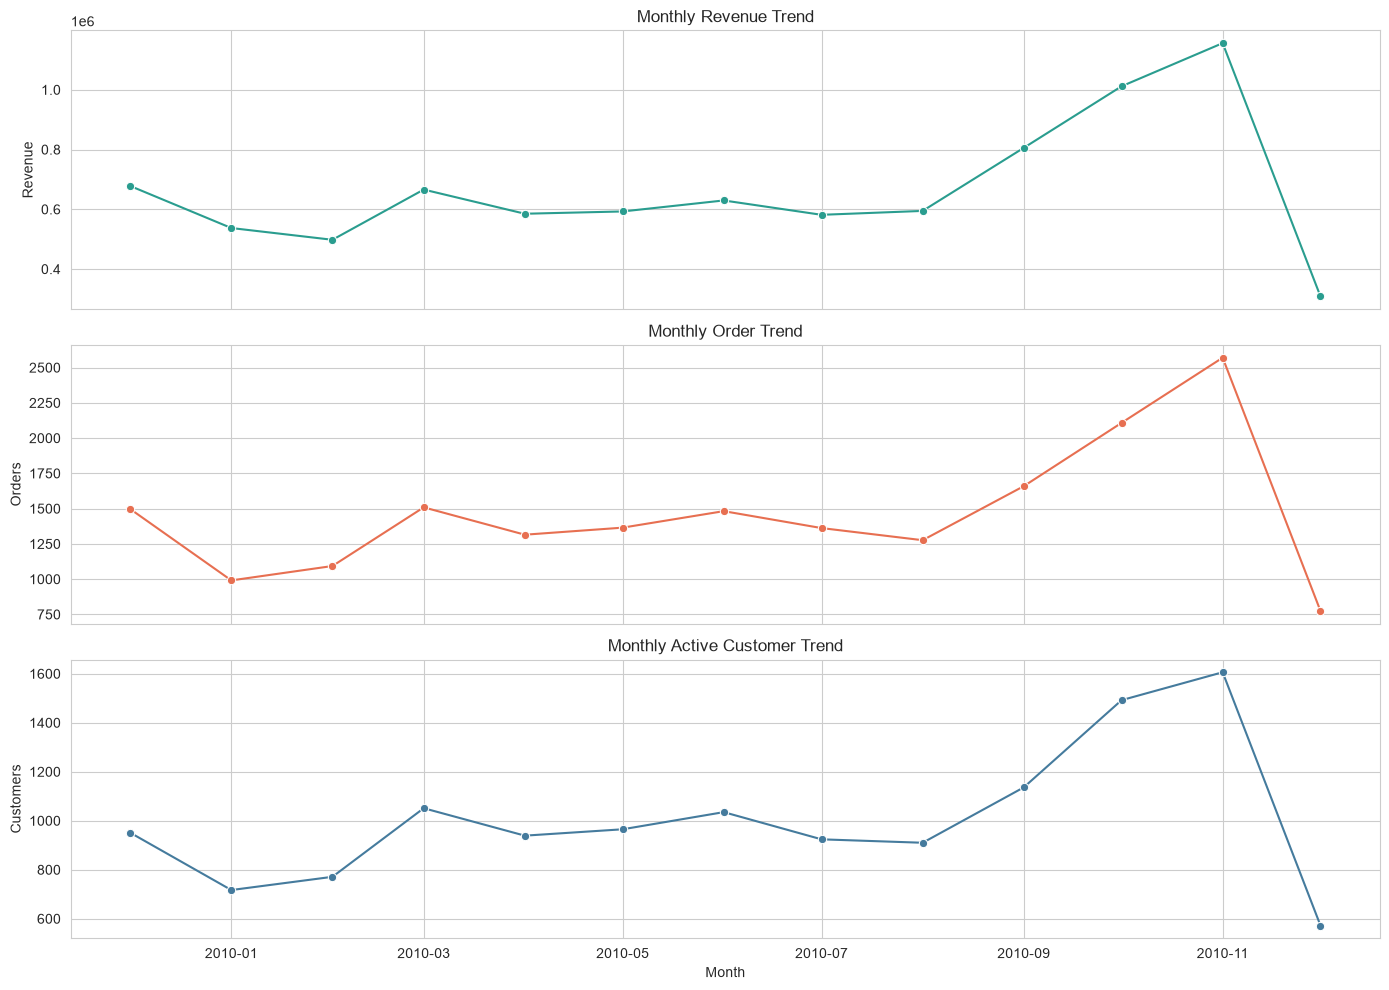

In [25]:
# Monthly business trend: revenue, orders, and active customers
monthly_trend = (
    df_purchase.assign(order_month=df_purchase['invoice_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('order_month')
    .agg(
        revenue=('line_amount', 'sum'),
        orders=('invoice_no', 'nunique'),
        active_customers=('customer_id', 'nunique')
    )
    .reset_index()
 )

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

sns.lineplot(data=monthly_trend, x='order_month', y='revenue', marker='o', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_ylabel('Revenue')

sns.lineplot(data=monthly_trend, x='order_month', y='orders', marker='o', ax=axes[1], color='#e76f51')
axes[1].set_title('Monthly Order Trend')
axes[1].set_ylabel('Orders')

sns.lineplot(data=monthly_trend, x='order_month', y='active_customers', marker='o', ax=axes[2], color='#457b9d')
axes[2].set_title('Monthly Active Customer Trend')
axes[2].set_ylabel('Customers')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

### Observation:
This shows whether the business is stable or seasonal over time. If sales, orders, and active customers rise and fall together, that gives useful context for churn because a drop in customer activity may be part of a broader seasonal pattern rather than a customer problem on its own.

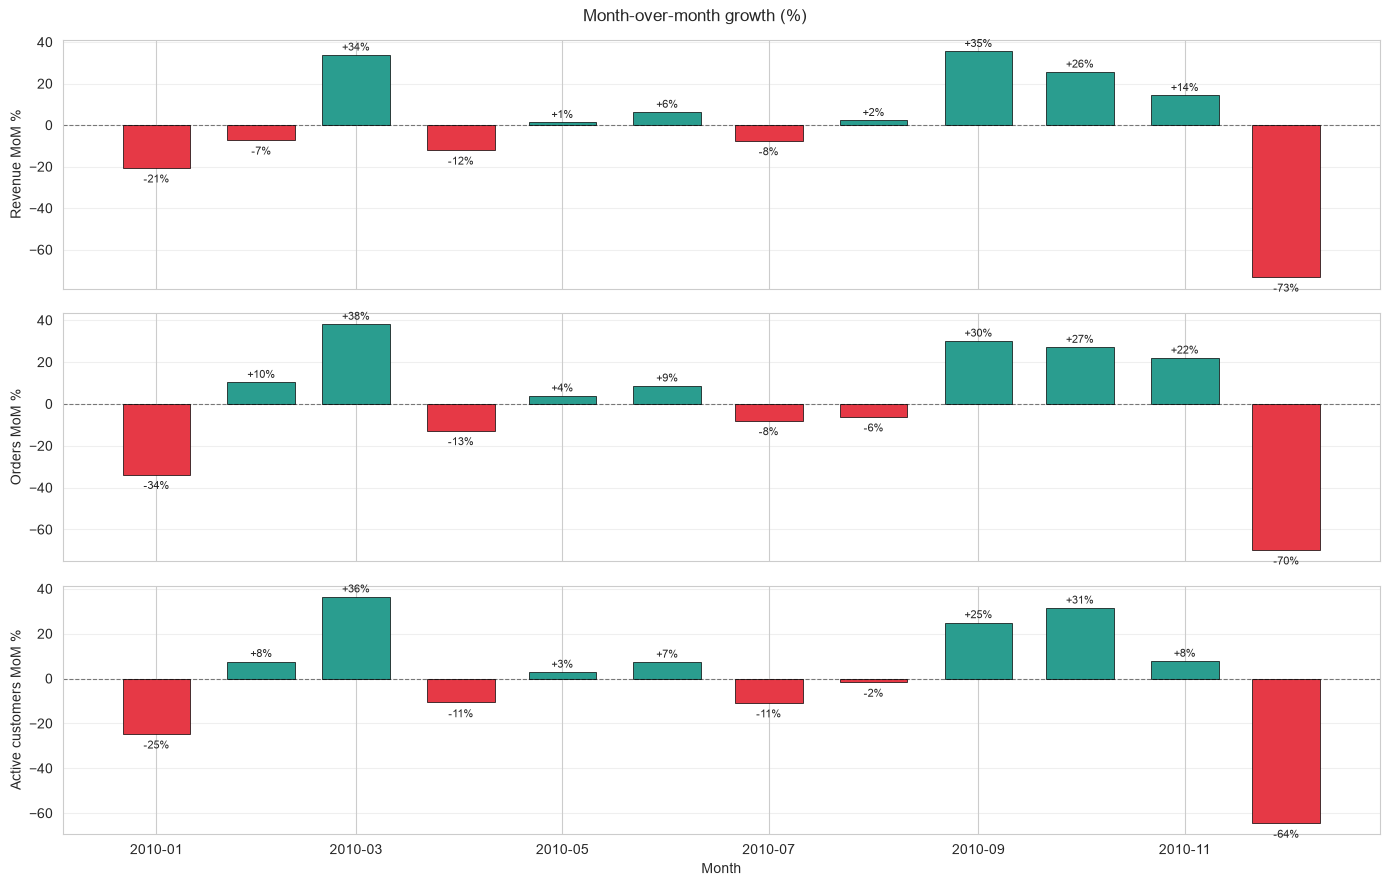

Peak revenue month:         Nov 2010
Lowest revenue month:       Dec 2010
Average MoM revenue growth: -0.2%


In [26]:
# Month-over-month growth rates
monthly_trend['revenue_mom_pct'] = monthly_trend['revenue'].pct_change() * 100
monthly_trend['orders_mom_pct'] = monthly_trend['orders'].pct_change() * 100
monthly_trend['customers_mom_pct'] = monthly_trend['active_customers'].pct_change() * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Month-over-month growth (%)')

color_pos = '#2a9d8f'
color_neg = '#e63946'

for ax, col, label in zip(
    axes,
    ['revenue_mom_pct', 'orders_mom_pct', 'customers_mom_pct'],
    ['Revenue MoM %', 'Orders MoM %', 'Active customers MoM %'],
):
    values = monthly_trend[col].dropna()
    months = monthly_trend.loc[values.index, 'order_month']
    bar_colors_mom = [color_pos if v >= 0 else color_neg for v in values]
    ax.bar(months, values, color=bar_colors_mom, edgecolor='black', linewidth=0.5, width=20)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
    for x, v in zip(months, values):
        ax.text(x, v + (1 if v >= 0 else -3), f'{v:+.0f}%', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8)

axes[2].set_xlabel('Month')
plt.tight_layout()
plt.show()

peak_month = monthly_trend.loc[monthly_trend['revenue'].idxmax(), 'order_month'].strftime('%b %Y')
trough_month = monthly_trend.loc[monthly_trend['revenue'].idxmin(), 'order_month'].strftime('%b %Y')
avg_mom_growth = monthly_trend['revenue_mom_pct'].mean()

print(f"Peak revenue month:         {peak_month}")
print(f"Lowest revenue month:       {trough_month}")
print(f"Average MoM revenue growth: {avg_mom_growth:+.1f}%")


### Observation:
Green bars show months of growth, red bars show contraction. The chart reveals the business ramps up strongly through autumn and peaks in November, with a sharp apparent drop in December 2010 that likely reflects the dataset ending mid-month rather than a real business decline. The average month-on-month growth rate and the clear peak month confirm a seasonal demand pattern that churn models should account for — a quiet month in December is expected, not a retention problem.

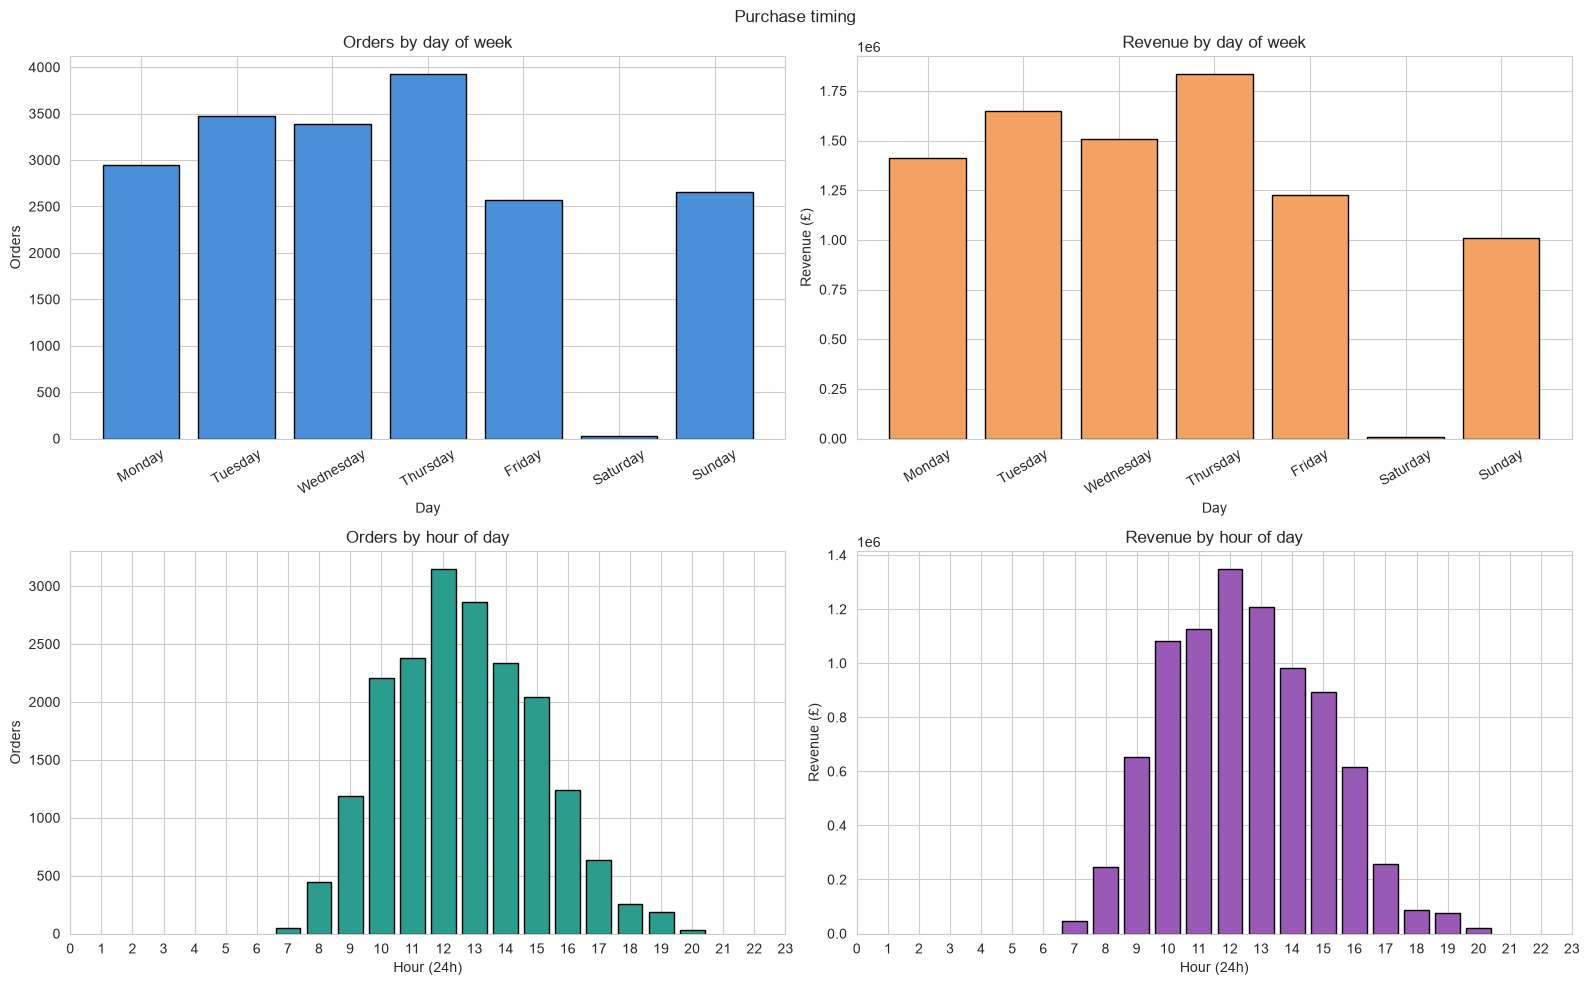

Busiest day:   Thursday | Quietest day: Saturday
Peak hour:     12:00
Weekend share: 2,689 orders (14.2% of total)


In [27]:
# Day-of-week and hour-of-day purchasing patterns
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_purchase_time = df_purchase.copy()
df_purchase_time['day_of_week'] = df_purchase_time['invoice_date'].dt.day_name()
df_purchase_time['hour_of_day'] = df_purchase_time['invoice_date'].dt.hour

dow_summary = (
    df_purchase_time.groupby('day_of_week')
    .agg(
        orders=('invoice_no', 'nunique'),
        revenue=('line_amount', 'sum'),
        customers=('customer_id', 'nunique')
    )
    .reindex(dow_order)
    .reset_index()
)

hod_summary = (
    df_purchase_time.groupby('hour_of_day')
    .agg(
        orders=('invoice_no', 'nunique'),
        revenue=('line_amount', 'sum')
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Purchase timing')

axes[0, 0].bar(dow_summary['day_of_week'], dow_summary['orders'], color='#4a90d9', edgecolor='black')
axes[0, 0].set_title('Orders by day of week')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Orders')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].bar(dow_summary['day_of_week'], dow_summary['revenue'], color='#f4a261', edgecolor='black')
axes[0, 1].set_title('Revenue by day of week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Revenue (£)')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].bar(hod_summary['hour_of_day'], hod_summary['orders'], color='#2a9d8f', edgecolor='black')
axes[1, 0].set_title('Orders by hour of day')
axes[1, 0].set_xlabel('Hour (24h)')
axes[1, 0].set_ylabel('Orders')
axes[1, 0].set_xticks(range(0, 24))

axes[1, 1].bar(hod_summary['hour_of_day'], hod_summary['revenue'], color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Revenue by hour of day')
axes[1, 1].set_xlabel('Hour (24h)')
axes[1, 1].set_ylabel('Revenue (£)')
axes[1, 1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

peak_day = dow_summary.loc[dow_summary['orders'].idxmax(), 'day_of_week']
lowest_day = dow_summary.loc[dow_summary['orders'].idxmin(), 'day_of_week']
peak_hour = hod_summary.loc[hod_summary['orders'].idxmax(), 'hour_of_day']
weekend_orders = dow_summary[dow_summary['day_of_week'].isin(['Saturday', 'Sunday'])]['orders'].sum()
weekend_pct = weekend_orders / dow_summary['orders'].sum() * 100

print(f"Busiest day:   {peak_day} | Quietest day: {lowest_day}")
print(f"Peak hour:     {peak_hour:02d}:00")
print(f"Weekend share: {weekend_orders:,} orders ({weekend_pct:.1f}% of total)")


### Observation:
The day-of-week and hour-of-day charts strongly suggest this is a B2B business. Orders peak during mid-week working days and drop sharply at weekends, with negligible activity on Sundays. The hour-of-day chart shows purchasing concentrated between 09:00 and 17:00, consistent with business procurement behaviour. This has a direct implication for churn modelling: a customer who stops ordering during business hours is showing qualitatively different behaviour than one who simply shifts to occasional weekend shopping.

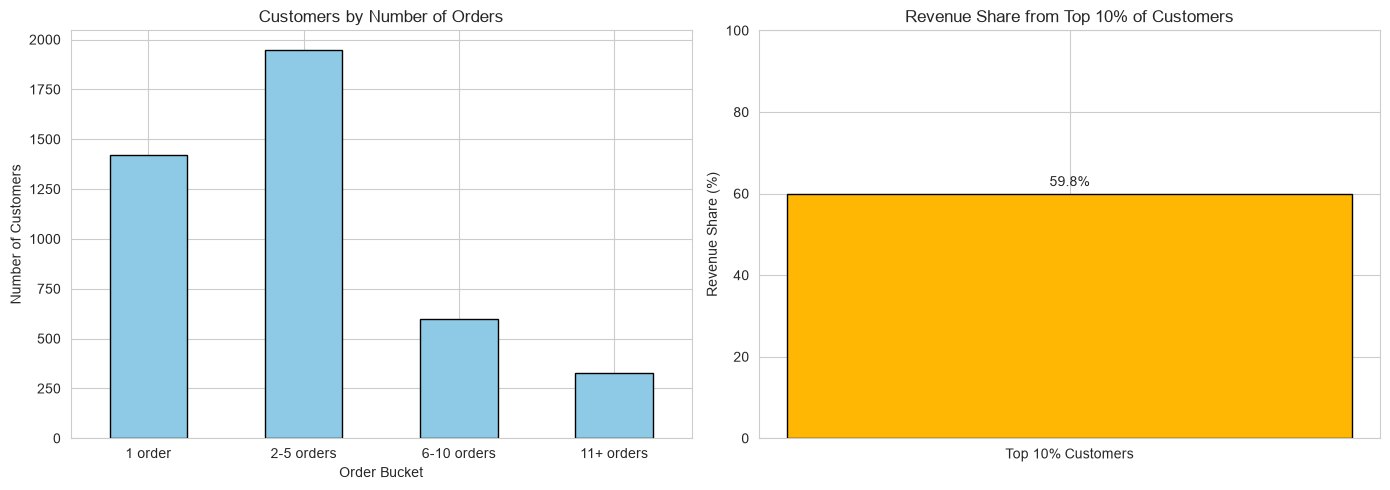

In [28]:
# Customer mix: one-time vs repeat buyers and revenue concentration
customer_summary = (
    df_purchase.groupby('customer_id')
    .agg(
        orders=('invoice_no', 'nunique'),
        spend=('line_amount', 'sum')
    )
    .reset_index()
 )

customer_summary['order_bucket'] = pd.cut(
    customer_summary['orders'],
    bins=[0, 1, 5, 10, np.inf],
    labels=['1 order', '2-5 orders', '6-10 orders', '11+ orders']
 )

bucket_counts = customer_summary['order_bucket'].value_counts().reindex(['1 order', '2-5 orders', '6-10 orders', '11+ orders']).fillna(0)
revenue_top_10_pct = customer_summary.nlargest(max(1, int(np.ceil(len(customer_summary) * 0.10))), 'spend')['spend'].sum() / customer_summary['spend'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_counts.plot(kind='bar', ax=axes[0], color='#8ecae6', edgecolor='black')
axes[0].set_title('Customers by Number of Orders')
axes[0].set_xlabel('Order Bucket')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(['Top 10% Customers'], [revenue_top_10_pct], color='#ffb703', edgecolor='black')
axes[1].set_title('Revenue Share from Top 10% of Customers')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].set_ylim(0, 100)
axes[1].text(0, revenue_top_10_pct + 2, f'{revenue_top_10_pct:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### Observation:
This tells us how much of the business depends on repeat customers and whether a small group of customers drives a large share of revenue. If most customers buy only once, churn risk is naturally high. If a small group contributes most revenue, keeping those customers matters even more.

Median days between orders: 20.0
90th percentile of days between orders: 101.0


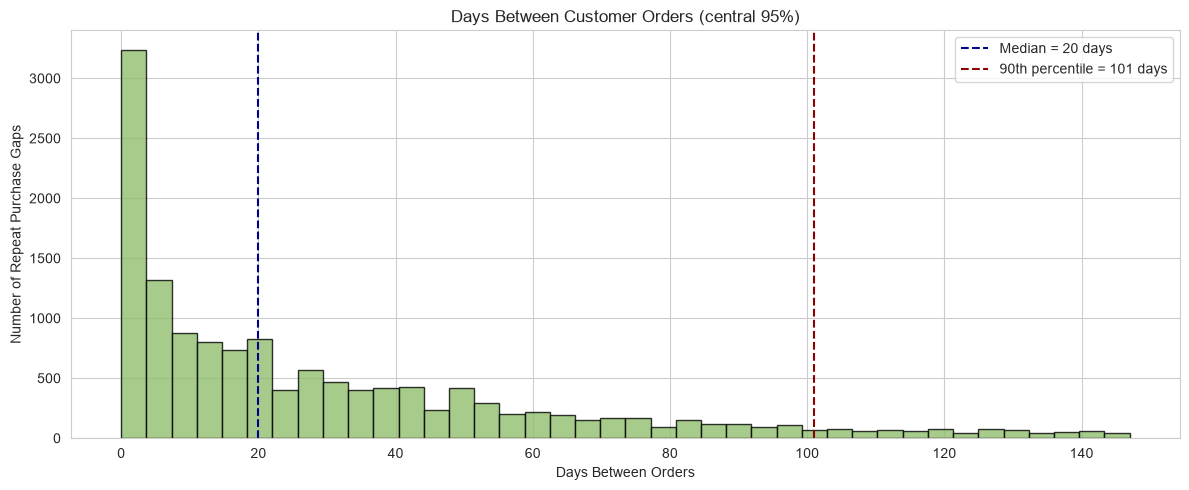

In [29]:
# Inter-purchase timing to support churn threshold discussion
purchase_events = (
    df_purchase[['customer_id', 'invoice_no', 'invoice_date']]
    .drop_duplicates()
    .sort_values(['customer_id', 'invoice_date'])
 )

purchase_events['days_since_previous_order'] = (
    purchase_events.groupby('customer_id')['invoice_date'].diff().dt.days
 )

gap_days = purchase_events['days_since_previous_order'].dropna()
gap_days_view = gap_days[gap_days <= gap_days.quantile(0.95)]

median_gap = gap_days.median() if not gap_days.empty else np.nan
p90_gap = gap_days.quantile(0.90) if not gap_days.empty else np.nan

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(gap_days_view, bins=40, color='#90be6d', edgecolor='black', alpha=0.8)
ax.axvline(median_gap, color='darkblue', linestyle='--', label=f'Median = {median_gap:.0f} days')
ax.axvline(p90_gap, color='darkred', linestyle='--', label=f'90th percentile = {p90_gap:.0f} days')
ax.set_title('Days Between Customer Orders (central 95%)')
ax.set_xlabel('Days Between Orders')
ax.set_ylabel('Number of Repeat Purchase Gaps')
ax.legend()

print(f'Median days between orders: {median_gap:.1f}')
print(f'90th percentile of days between orders: {p90_gap:.1f}')

plt.tight_layout()
plt.show()

### Observation:
This is one of the most useful views for churn work because it shows how long customers normally take to return. The median gives the typical repeat-buying gap, while the 90th percentile gives a practical upper limit for many returning customers. That makes it a good starting point when choosing an inactivity threshold for churn.

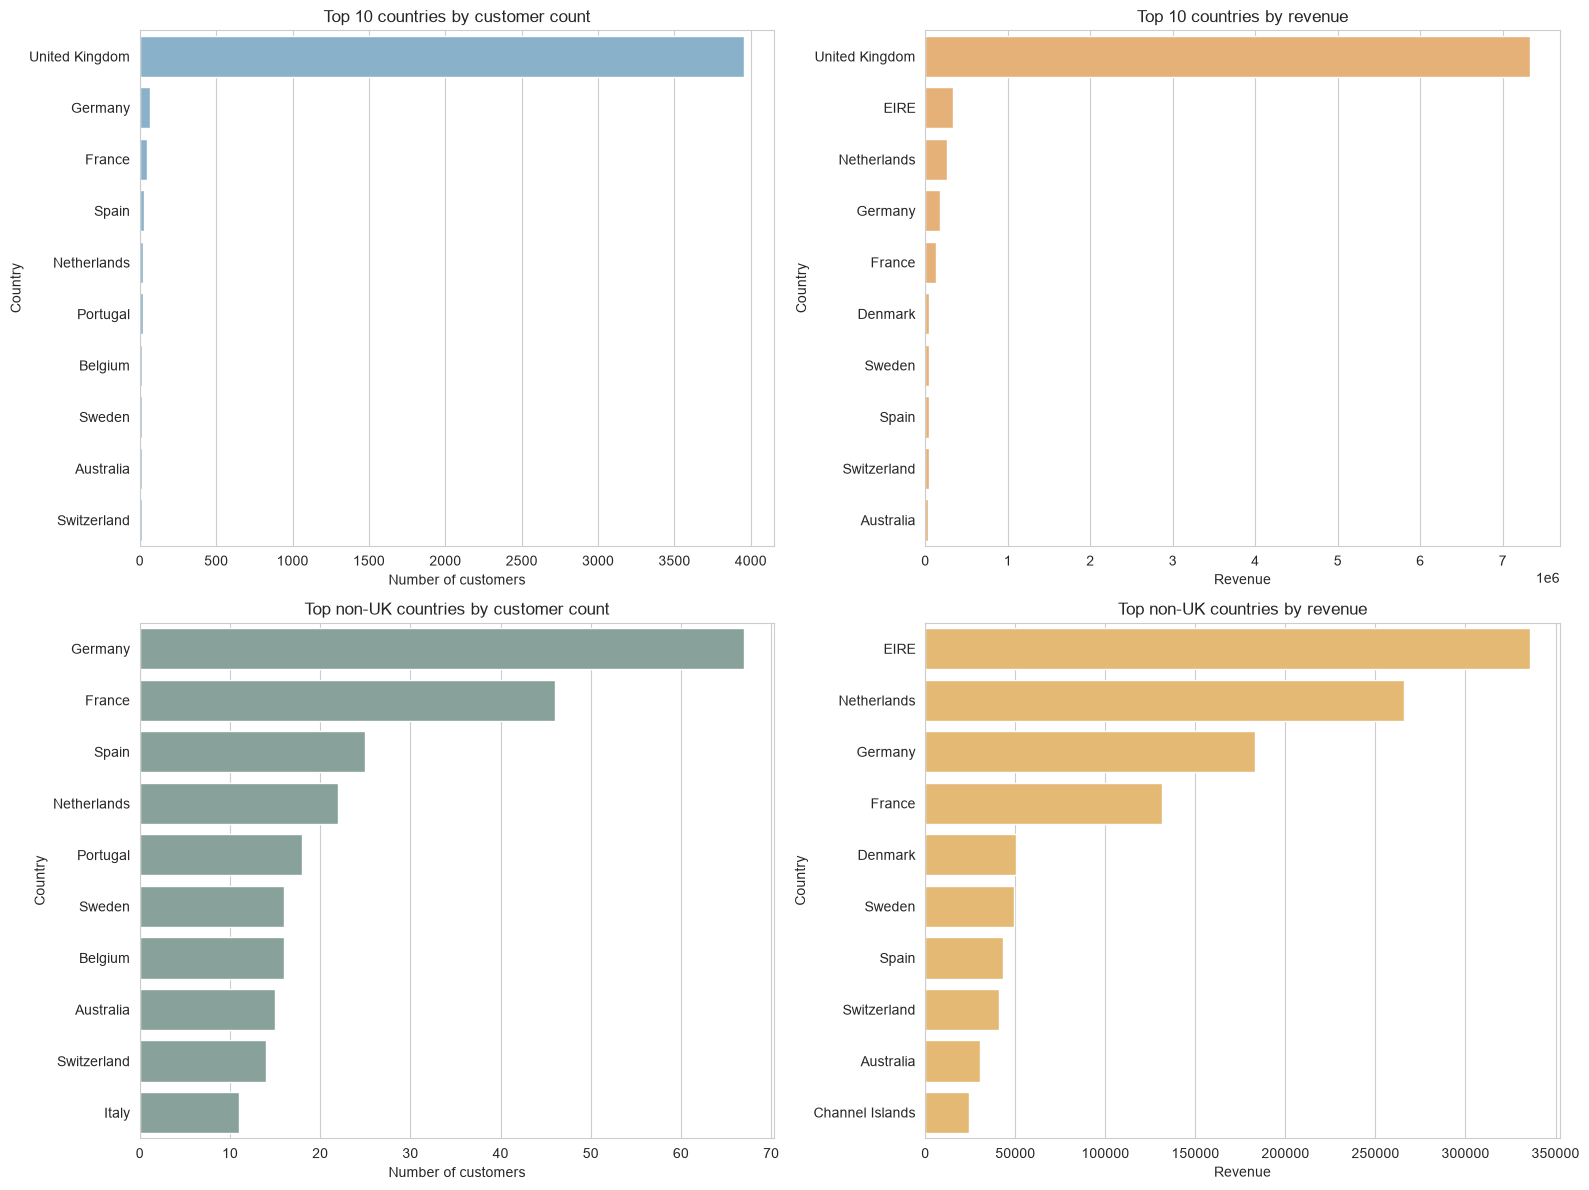

In [30]:
# Country contribution: top countries by customers and revenue
country_summary = (
    df_purchase.groupby('country')
    .agg(
        customers=('customer_id', 'nunique'),
        revenue=('line_amount', 'sum')
    )
    .reset_index()
 )

top_countries_customers = country_summary.sort_values('customers', ascending=False).head(10)
top_countries_revenue = country_summary.sort_values('revenue', ascending=False).head(10)
non_uk_summary = country_summary[country_summary['country'] != 'United Kingdom'].copy()
top_non_uk_customers = non_uk_summary.sort_values('customers', ascending=False).head(10)
top_non_uk_revenue = non_uk_summary.sort_values('revenue', ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=top_countries_customers, y='country', x='customers', ax=axes[0, 0], color='#7fb3d5')
axes[0, 0].set_title('Top 10 countries by customer count')
axes[0, 0].set_xlabel('Number of customers')
axes[0, 0].set_ylabel('Country')

sns.barplot(data=top_countries_revenue, y='country', x='revenue', ax=axes[0, 1], color='#f7b267')
axes[0, 1].set_title('Top 10 countries by revenue')
axes[0, 1].set_xlabel('Revenue')
axes[0, 1].set_ylabel('Country')

sns.barplot(data=top_non_uk_customers, y='country', x='customers', ax=axes[1, 0], color='#84a59d')
axes[1, 0].set_title('Top non-UK countries by customer count')
axes[1, 0].set_xlabel('Number of customers')
axes[1, 0].set_ylabel('Country')

sns.barplot(data=top_non_uk_revenue, y='country', x='revenue', ax=axes[1, 1], color='#f6bd60')
axes[1, 1].set_title('Top non-UK countries by revenue')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Country')

plt.tight_layout()
plt.show()


### Observation:
The first two charts show the full picture, including the United Kingdom, which clearly dominates the business. The second row removes the UK so the other countries are easier to compare. This makes it easier to see which non-UK markets are strongest and where the business may have room to grow outside its main market.

Customers who returned at least once: 38.8%


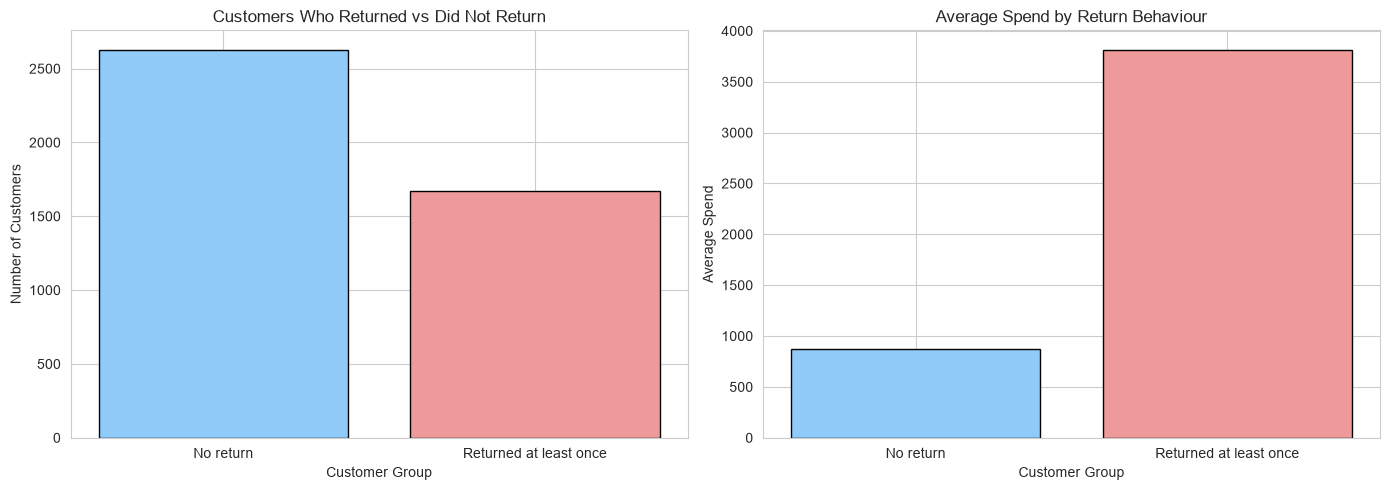

In [31]:
# Return behaviour: how many customers ever return and how they compare
return_events = df_clean[(df_clean['quantity'] < 0) | (df_clean['price'] < 0) | (df_clean['invoice_no'].astype(str).str.startswith('C', na=False))].copy()

customer_purchase_summary = (
    df_purchase.groupby('customer_id')
    .agg(
        total_spend=('line_amount', 'sum'),
        total_orders=('invoice_no', 'nunique')
    )
    .reset_index()
 )

returning_customers = return_events['customer_id'].dropna().astype(str).str.replace('.0', '', regex=False).unique()
customer_purchase_summary['ever_returned'] = customer_purchase_summary['customer_id'].isin(returning_customers)

return_rate = customer_purchase_summary['ever_returned'].mean() * 100
return_compare = customer_purchase_summary.groupby('ever_returned').agg(
    customers=('customer_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    avg_orders=('total_orders', 'mean')
).reset_index()
return_compare['ever_returned'] = return_compare['ever_returned'].map({False: 'No return', True: 'Returned at least once'})

group_colors = {'No return': '#90caf9', 'Returned at least once': '#ef9a9a'}
bar_colors = [group_colors[group] for group in return_compare['ever_returned']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(return_compare['ever_returned'], return_compare['customers'], color=bar_colors, edgecolor='black')
axes[0].set_title('Customers Who Returned vs Did Not Return')
axes[0].set_xlabel('Customer Group')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(return_compare['ever_returned'], return_compare['avg_spend'], color=bar_colors, edgecolor='black')
axes[1].set_title('Average Spend by Return Behaviour')
axes[1].set_xlabel('Customer Group')
axes[1].set_ylabel('Average Spend')
axes[1].tick_params(axis='x', rotation=0)

print(f'Customers who returned at least once: {return_rate:.1f}%')

plt.tight_layout()
plt.show()

### Observation:
About 40% of customers have made at least one return. Notably, customers who returned items show considerably higher average spend than those who never returned. This suggests returners are generally more engaged, higher-volume buyers rather than low-value or problematic customers. Return behaviour alone should not be treated as a churn warning signal without further context from the statistical tests below.

## Returners vs non-returners
A quick t-test to see whether return behaviour separates customers in any meaningful way.


In [32]:
from scipy import stats
from typing import cast

returners = customer_purchase_summary[customer_purchase_summary['ever_returned']]
non_returners = customer_purchase_summary[~customer_purchase_summary['ever_returned']]

test_results = []
for metric in ['total_spend', 'total_orders']:
    # Welch's t-test (equal_var=False): returners and non-returners differ greatly
    # in group size and variance, so we do not assume equal population variances.
    test_result = cast(
        tuple[float, float],
        stats.ttest_ind(
            returners[metric].dropna(),
            non_returners[metric].dropna(),
            equal_var=False,
        ),
    )
    t_stat = float(test_result[0])
    p_value = float(test_result[1])

    test_results.append({
        'Metric': metric,
        'Returners Mean': round(float(returners[metric].mean()), 2),
        'Non-Returners Mean': round(float(non_returners[metric].mean()), 2),
        'T-Statistic': round(t_stat, 3),
        'P-Value': round(p_value, 4),
        'Significant (a=0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

test_df = pd.DataFrame(test_results)
display(test_df)

for _, row in test_df.iterrows():
    verdict = 'significantly different' if row['Significant (a=0.05)'] == 'Yes' else 'not significantly different'
    print(f"{row['Metric']}: returners vs non-returners are {verdict} (p = {row['P-Value']})")


,Metric,Returners Mean,Non-Returners Mean,T-Statistic,P-Value,Significant (a=0.05)
0,total_spend,3813.30,869.18,8.680,0.0,Yes
1,total_orders,7.52,2.46,17.285,0.0,Yes


total_spend: returners vs non-returners are significantly different (p = 0.0)
total_orders: returners vs non-returners are significantly different (p = 0.0)


### Observation:
Welch's t-test (which does not assume equal variances) confirms the difference between returners and non-returners is statistically significant for both spend and order count (p < 0.0001). Returners spend about 4.4× more on average (£3,813 vs £869) and place roughly 3× more orders (7.5 vs 2.5) than non-returners. This means return behaviour is not random noise — it is a genuine signal of higher customer engagement. The `ever_returned` flag should be included as a feature in the churn model.


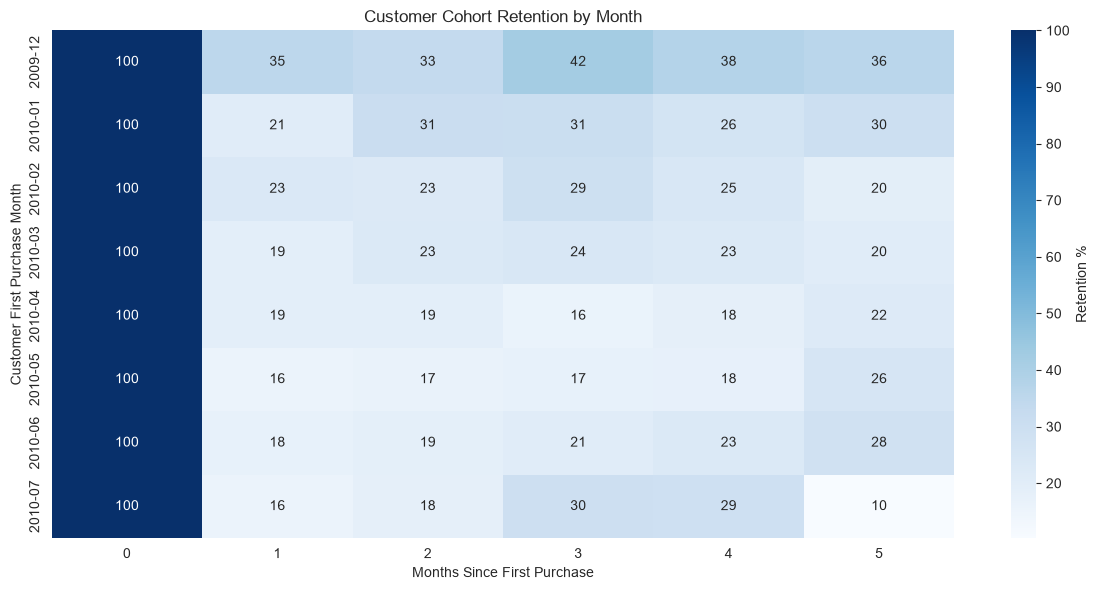

In [33]:
# Cohort retention: how customer groups behave after their first purchase month
cohort_data = df_purchase[['customer_id', 'invoice_date']].drop_duplicates().copy()
cohort_data['invoice_month'] = cohort_data['invoice_date'].dt.to_period('M')
cohort_data['cohort_month'] = cohort_data.groupby('customer_id')['invoice_month'].transform('min')
cohort_data['cohort_index'] = (cohort_data['invoice_month'] - cohort_data['cohort_month']).apply(lambda period: period.n)

cohort_counts = (
    cohort_data.groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
 )

cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_view = retention_matrix.iloc[:8, :6] * 100

plt.figure(figsize=(12, 6))
sns.heatmap(retention_view, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Retention %'})
plt.title('Customer Cohort Retention by Month')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer First Purchase Month')
plt.tight_layout()
plt.show()

### Observation:
This chart shows how well the business keeps customers after their first purchase month. If the percentages drop quickly from left to right, it means many customers do not come back often. That makes the chart especially useful for understanding churn and spotting whether newer customer groups are behaving better or worse than older ones.

### EDA Summary:
The additional EDA confirms several key patterns that will inform churn modelling. Customer and product revenue are highly concentrated (Gini > 0.70), purchasing follows clear business-hours and weekday patterns, cohort retention drops sharply after the first month, and high-value customers are also the most likely to make returns. Together, these findings determine which features will be most predictive and how the model should handle false negatives for top-value customer segments.

## Export the customer analytical base


In [34]:
# Record observation date (used by notebook 3 for the churn inactivity window)
observation_date = df_purchase['invoice_date'].max()

# Customer-level analytical base (Task 1 deliverable)
out_customer_enhanced = BASE_DIR / 'customer_analytical_base_enhanced.csv'
customer_base.to_csv(out_customer_enhanced, index=False)

# Cleaned transaction-level table — input for notebook 2 (feature engineering).
# This is df_clean (duplicates dropped, missing customer/date removed, special /
# non-product stock codes excluded) and still contains both purchase and
# return / cancellation rows so downstream notebooks can derive RFM, returns, etc.
# 'price' is renamed to 'unit_price' to match the column name notebook 2 expects.
clean_tx_cols = ['invoice_no', 'stock_code', 'description', 'quantity',
                 'invoice_date', 'price', 'customer_id', 'country']
clean_transactions = df_clean[clean_tx_cols].rename(columns={'price': 'unit_price'})
out_clean_tx = BASE_DIR / 'clean_transactions.csv'
clean_transactions.to_csv(out_clean_tx, index=False)

# Summary metadata
metadata = {
    'Analysis Date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Data Period': f"{df['invoice_date'].min().date()} to {df['invoice_date'].max().date()}",
    'Observation Date (for churn window)': observation_date.strftime('%Y-%m-%d'),
    'Raw Records': len(df),
    'Cleaned Records': len(df_clean),
    'Purchase Records': len(df_purchase),
    'Return / Cancellation Records': len(df_return),
    'Special Stock-Code Rows Removed': int(special_rows_removed),
    'Total Customers': customer_base.shape[0],
    'Gross Revenue (£)': f"{customer_base['total_spend'].sum():,.2f}",
    'Net Revenue after Returns (£)': f"{customer_base['net_spend'].sum():,.2f}",
    'Avg Customer Net Spend (£)': f"{customer_base['net_spend'].mean():,.2f}",
    'Median Customer Net Spend (£)': f"{customer_base['net_spend'].median():,.2f}",
    'Unique Countries': df['country'].nunique(),
    'Customer Gini Coefficient': f"{gini_spend:.3f}",
    'RFM Segments Identified': customer_base['rfm_segment'].nunique(),
}

metadata_df = pd.DataFrame(list(metadata.items()), columns=['Metric', 'Value'])
metadata_df.to_csv(BASE_DIR / 'eda_metadata.csv', index=False)

# Data dictionary for the exported customer analytical base
data_dictionary = pd.DataFrame([
    ('customer_id',           'string',   'Unique customer identifier'),
    ('first_purchase',        'datetime', "Timestamp of customer's first purchase"),
    ('last_purchase',         'datetime', "Timestamp of customer's most recent purchase"),
    ('purchase_lines',        'int',      'Total number of purchase line items'),
    ('unique_invoices',       'int',      'Number of distinct invoices (orders)'),
    ('total_quantity',        'int',      'Total units purchased'),
    ('total_spend',           'float',    'Gross spend across all purchase lines (£)'),
    ('avg_unit_price',        'float',    'Mean unit price across purchase lines (£)'),
    ('countries',             'int',      'Number of distinct countries the customer ordered from'),
    ('distinct_products',     'int',      'Number of unique stock codes purchased'),
    ('days_active',           'int',      'Count of distinct calendar days with a purchase'),
    ('primary_country',       'string',   'Most frequent country for the customer'),
    ('return_count',          'int',      'Number of return / cancellation lines'),
    ('return_value',          'float',    'Sum of return line amounts (negative, £)'),
    ('customer_tenure_days',  'int',      'Days between first and last purchase'),
    ('net_spend',             'float',    'total_spend + return_value (net of refunds, £)'),
    ('avg_basket_size',       'float',    'purchase_lines / unique_invoices'),
    ('avg_order_value',       'float',    'total_spend / unique_invoices (£)'),
    ('return_rate',           'float',    'return_count / unique_invoices'),
    ('first_purchase_month',  'string',   'YYYY-MM of first purchase (cohort key)'),
    ('country_group',         'string',   'UK / EU / Other rollup of primary_country'),
    ('spend_quartile',        'category', 'Quartile of total_spend (Q1 lowest .. Q4 highest)'),
    ('frequency_segment',     'category', 'One-time / Occasional / Regular / Loyal'),
    ('recency_days',          'int',      'Days from last_purchase to observation_date'),
    ('frequency',             'int',      'RFM frequency = unique_invoices'),
    ('monetary',              'float',    'RFM monetary = total_spend (£)'),
    ('r_score',               'int',      'RFM recency score (1-4)'),
    ('f_score',               'int',      'RFM frequency score (1-4)'),
    ('m_score',               'int',      'RFM monetary score (1-4)'),
    ('rfm_score',             'int',      'Combined RFM code (r*100 + f*10 + m)'),
    ('rfm_segment',           'string',   'Named RFM segment (Champions, At Risk, etc.)'),
], columns=['column', 'dtype', 'description'])
data_dictionary.to_csv(BASE_DIR / 'customer_base_data_dictionary.csv', index=False)

print("Summary metrics:")
display(metadata_df)

print("Data dictionary:")
display(data_dictionary)

print("Exported files:")
print(f"- {out_customer_enhanced.name}  ({customer_base.shape[0]:,} customers x {customer_base.shape[1]} features)")
print(f"- {out_clean_tx.name}  ({len(clean_transactions):,} cleaned transaction rows)")
print(f"- eda_metadata.csv  (observation_date = {observation_date.date()})")
print(f"- customer_base_data_dictionary.csv")


Summary metrics:


,Metric,Value
0,Analysis Date,2026-06-25 15:11:32
1,Data Period,2009-12-01 to 2010-12-09
2,Observation Date (for churn window),2010-12-09
3,Raw Records,525461
4,Cleaned Records,409018
5,Purchase Records,399589
6,Return / Cancellation Records,9401
7,Special Stock-Code Rows Removed,1745
8,Total Customers,4295
9,Gross Revenue (£),"8,643,926.77"


Data dictionary:


,column,dtype,description
0,customer_id,string,Unique customer identifier
1,first_purchase,datetime,Timestamp of customer's first purchase
2,last_purchase,datetime,Timestamp of customer's most recent purchase
3,purchase_lines,int,Total number of purchase line items
4,unique_invoices,int,Number of distinct invoices (orders)
5,total_quantity,int,Total units purchased
6,total_spend,float,Gross spend across all purchase lines (£)
7,avg_unit_price,float,Mean unit price across purchase lines (£)
8,countries,int,Number of distinct countries the customer orde...
9,distinct_products,int,Number of unique stock codes purchased


Exported files:
- customer_analytical_base_enhanced.csv  (4,295 customers x 31 features)
- clean_transactions.csv  (409,018 cleaned transaction rows)
- eda_metadata.csv  (observation_date = 2010-12-09)
- customer_base_data_dictionary.csv
